In [1]:
from pathlib import Path

base_dir = Path("PSMAB37")

spect_dir = base_dir / "SPECT"
ct_dir = base_dir / "CT"
seg_dir = base_dir / "SEGMENTATIONS"

print("SPECT:", len(list(spect_dir.glob("*.dcm"))))
print("CT:", len(list(ct_dir.glob("*.dcm"))))
print("SEG:", len(list(seg_dir.glob("*.dcm"))))

SPECT: 300
CT: 391
SEG: 1


In [2]:
import pydicom
from pathlib import Path

for f in Path("PSMAB37/SEGMENTATIONS").glob("*.dcm"):
    ds = pydicom.dcmread(f, stop_before_pixels=True)

    print("Archivo:", f.name)
    print("Modality:", ds.Modality)

    if hasattr(ds, "SeriesDescription"):
        print("SeriesDescription:", ds.SeriesDescription)

    break

Archivo: 1-1.dcm
Modality: SEG
SeriesDescription: Segmentation - Tumor lesions detected


In [3]:
import SimpleITK as sitk

reader = sitk.ImageSeriesReader()

files = reader.GetGDCMSeriesFileNames("PSMAB37/SPECT")
reader.SetFileNames(files)

spect_img = reader.Execute()

print("Size:", spect_img.GetSize())
print("Spacing:", spect_img.GetSpacing())
print(type(spect_img))

Size: (256, 256, 299)
Spacing: (2.734375, 2.734375, 3.270000022529765)
<class 'SimpleITK.SimpleITK.Image'>


In [4]:
import SimpleITK as sitk
import numpy as np

spect_array = sitk.GetArrayFromImage(spect_img)

print("Shape:", spect_array.shape)
print("Mínimo:", spect_array.min())
print("Máximo:", spect_array.max())
print("Tipo:", spect_array.dtype)

Shape: (299, 256, 256)
Mínimo: 0.0
Máximo: 52344.29949
Tipo: float64


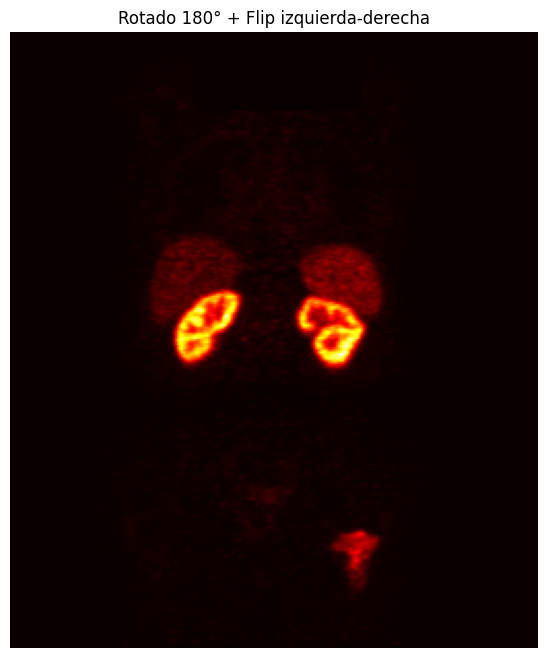

In [5]:
import matplotlib.pyplot as plt
import numpy as np

coronal_137 = spect_array[:, 137, :]
plt.figure(figsize=(8,8))
plt.imshow(np.fliplr(np.rot90(coronal_137, 2)), cmap="hot")
plt.title("Rotado 180° + Flip izquierda-derecha")
plt.axis("off")
plt.show()

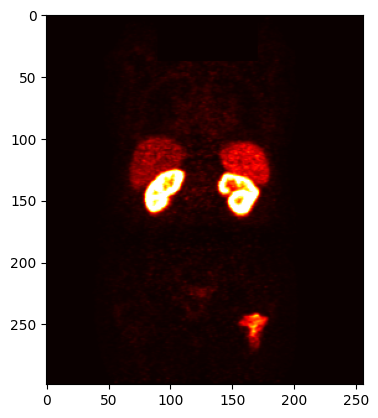

In [6]:
coronal_137_vis = np.fliplr(
    np.rot90(coronal_137, 2)
)
plt.imshow(coronal_137_vis,
           cmap="hot",
           vmin=0,
           vmax=np.percentile(coronal_137_vis,99))

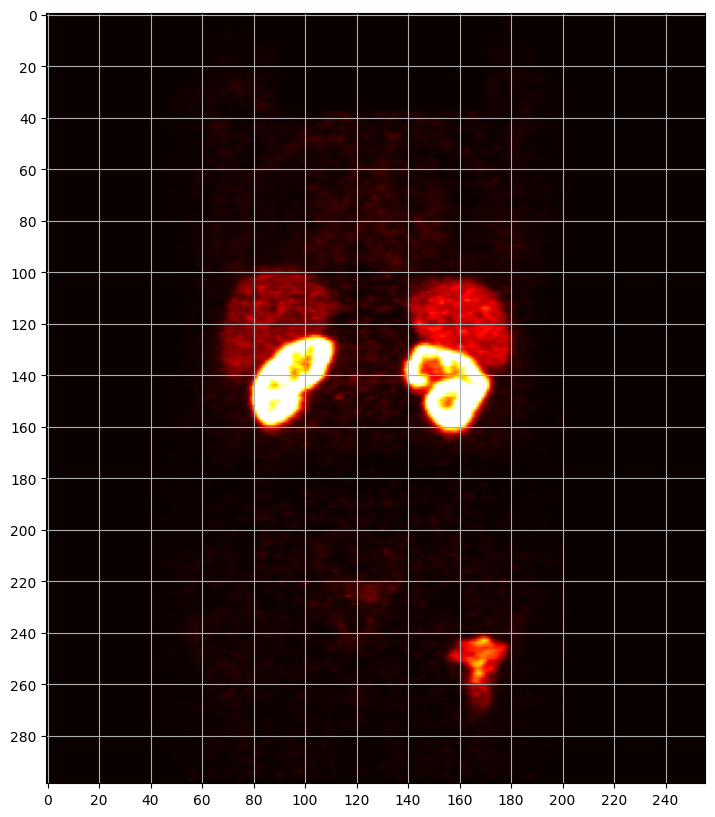

In [7]:
plt.figure(figsize=(10,10))

plt.imshow(
    coronal_137_vis,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(coronal_137_vis,99)
)

plt.xticks(np.arange(0,256,20))
plt.yticks(np.arange(0,299,20))

plt.grid(True)
plt.show()

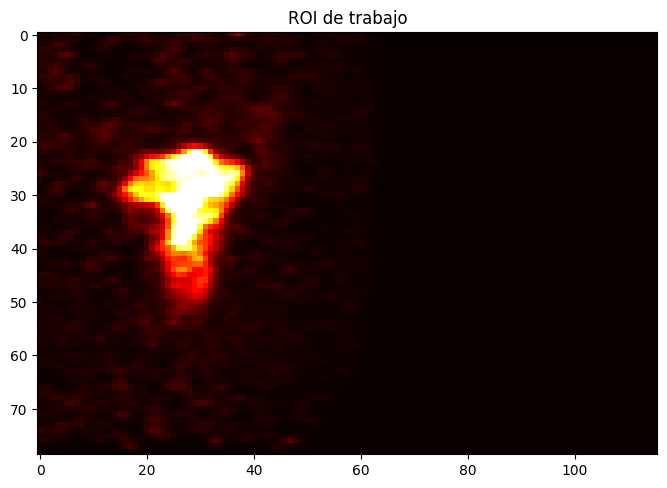

In [8]:
roi_img = coronal_137_vis[220:, 140:]
plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.title("ROI de trabajo")
plt.show()

### Umbralizacion

In [9]:
print("Min:", roi_img.min())
print("Max:", roi_img.max())

for p in [50, 75, 90, 95, 99]:
    print(f"P{p}: {np.percentile(roi_img, p):.2f}")

Min: 0.0
Max: 19446.121314
P50: 105.84
P75: 352.96
P90: 729.59
P95: 1776.94
P99: 11974.32


In [10]:
threshold = 0.70 * roi_img.max()
mask0 = roi_img > threshold

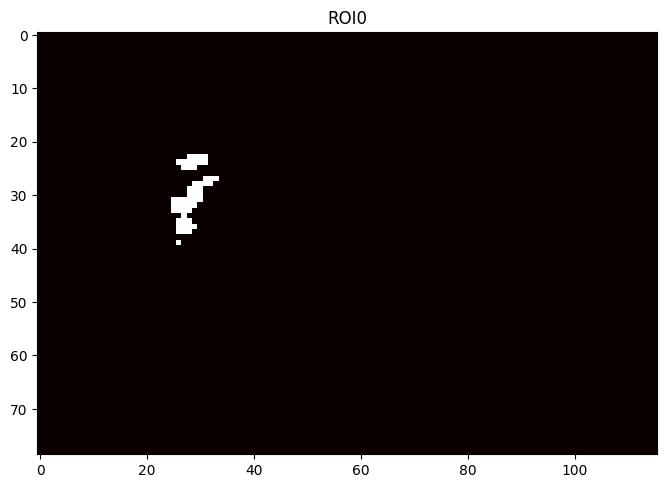

In [11]:
plt.figure(figsize=(8,8))
plt.imshow(mask0, cmap="hot")
plt.title("ROI0")
plt.show()

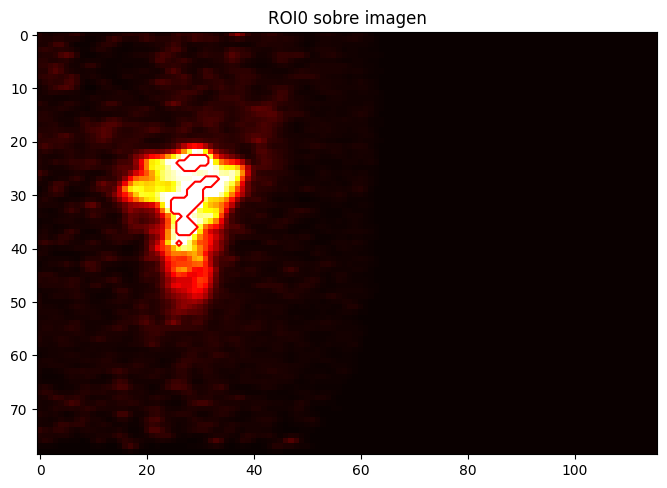

In [12]:
plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.contour(mask0, colors='r')

plt.title("ROI0 sobre imagen")
plt.show()

In [13]:
print("Número de píxeles:", mask0.sum())

Número de píxeles: 53


In [14]:
from scipy.ndimage import binary_dilation

mask1 = binary_dilation(mask0)

In [15]:
print("ROI0:", mask0.sum())
print("ROI1:", mask1.sum())

ROI0: 53
ROI1: 104


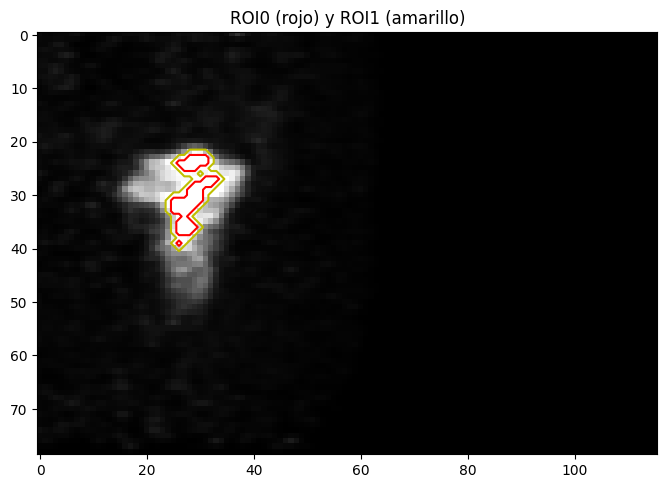

In [16]:
plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.contour(mask0, colors='r')
plt.contour(mask1, colors='y')

plt.title("ROI0 (rojo) y ROI1 (amarillo)")
plt.show()

### Radiomica

In [17]:
import SimpleITK as sitk

sitk_img = sitk.GetImageFromArray(
    roi_img.astype(np.float32)
)

sitk_mask0 = sitk.GetImageFromArray(
    mask0.astype(np.uint8)
)

sitk_mask1 = sitk.GetImageFromArray(
    mask1.astype(np.uint8)
)

In [18]:
from radiomics import featureextractor

extractor = featureextractor.RadiomicsFeatureExtractor()

extractor.disableAllFeatures()

extractor.enableFeatureClassByName("firstorder")

In [19]:
result0 = extractor.execute(
    sitk_img,
    sitk_mask0
)

mean0 = result0["original_firstorder_Mean"]

print("Mean ROI0 =", mean0)

Mean ROI0 = 15471.416568396226


In [20]:

result1 = extractor.execute(
    sitk_img,
    sitk_mask1
)

mean1 = result1["original_firstorder_Mean"]

print("Mean ROI1 =", mean1)

Mean ROI1 = 13765.107891376201


In [21]:
delta = abs(mean1 - mean0) / mean0

print("Delta =", delta)

Delta = 0.11028781168658695


#### Haciendo 10 bucles:

Iteración  0 | Área =   53 | Mean =   15471.42 | Delta =   0.00%


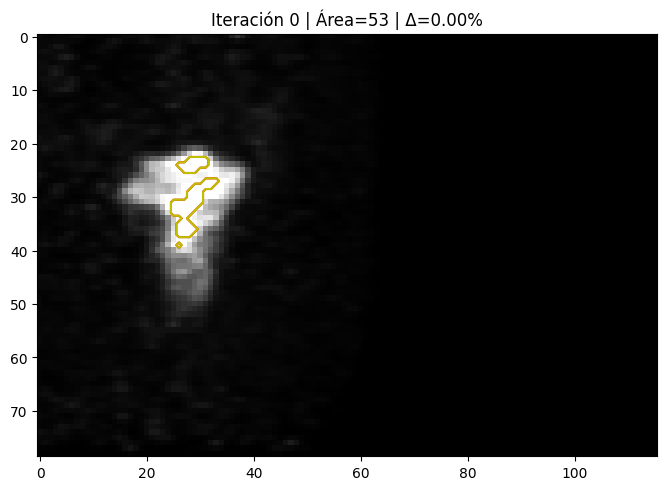

Iteración  1 | Área =  104 | Mean =   13765.11 | Delta =  11.03%


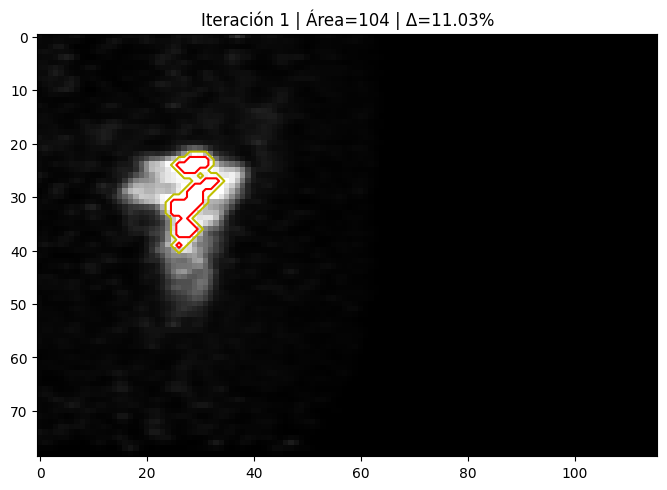

Iteración  2 | Área =  152 | Mean =   12270.20 | Delta =  20.69%


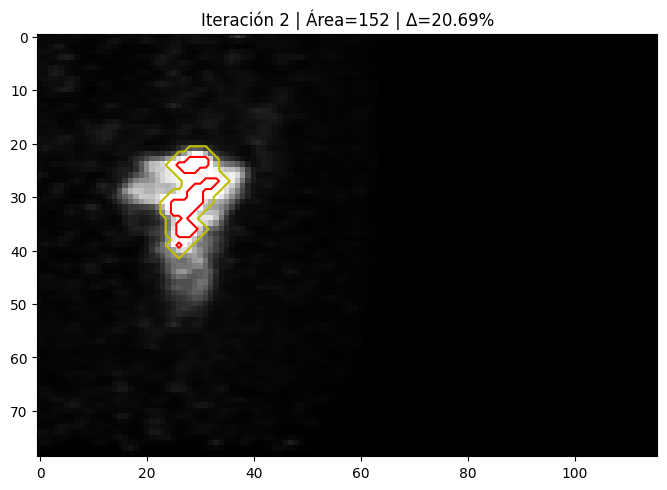

Iteración  3 | Área =  201 | Mean =   10929.27 | Delta =  29.36%


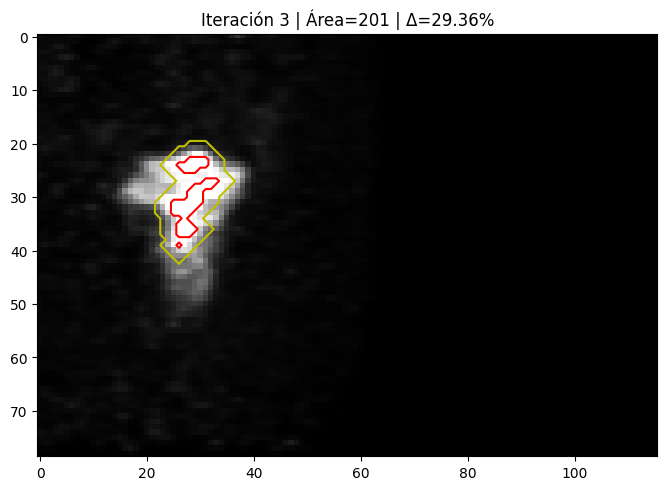

Iteración  4 | Área =  253 | Mean =    9822.77 | Delta =  36.51%


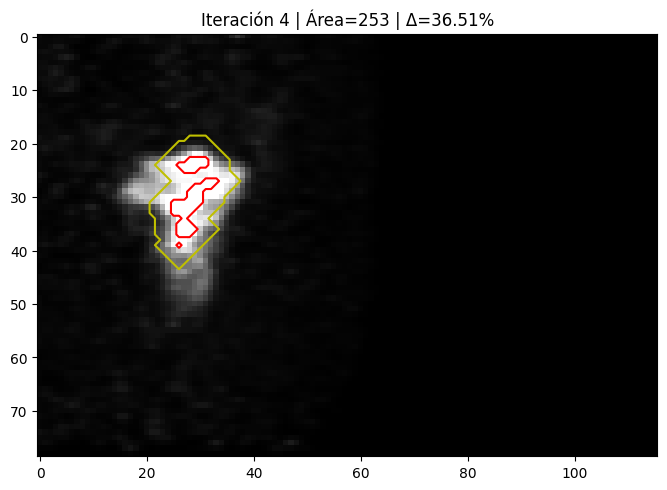

Iteración  5 | Área =  309 | Mean =    8904.66 | Delta =  42.44%


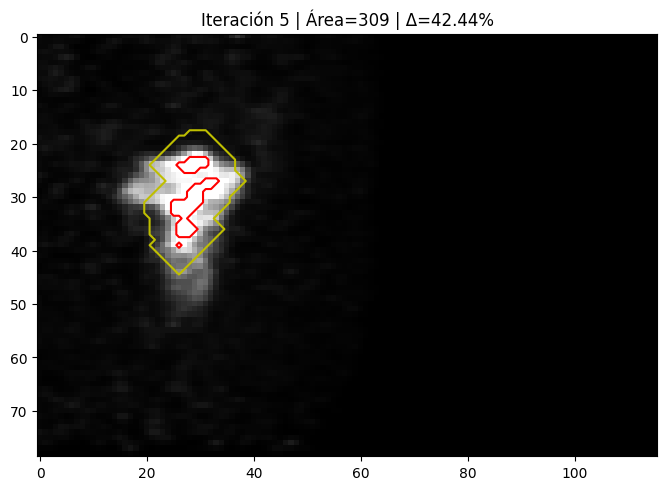

Iteración  6 | Área =  369 | Mean =    8084.40 | Delta =  47.75%


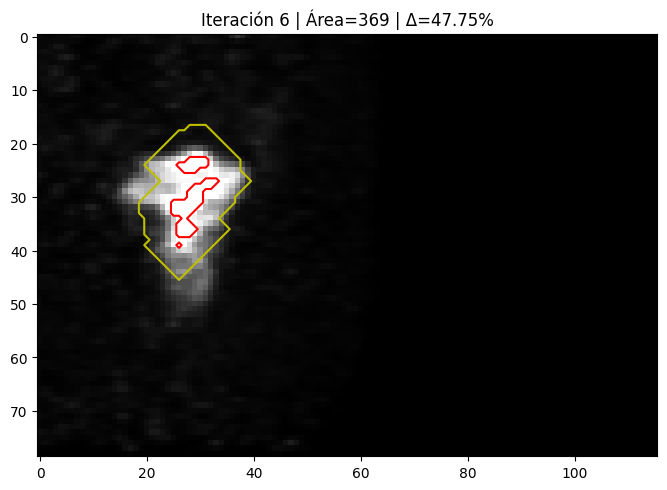

Iteración  7 | Área =  433 | Mean =    7316.18 | Delta =  52.71%


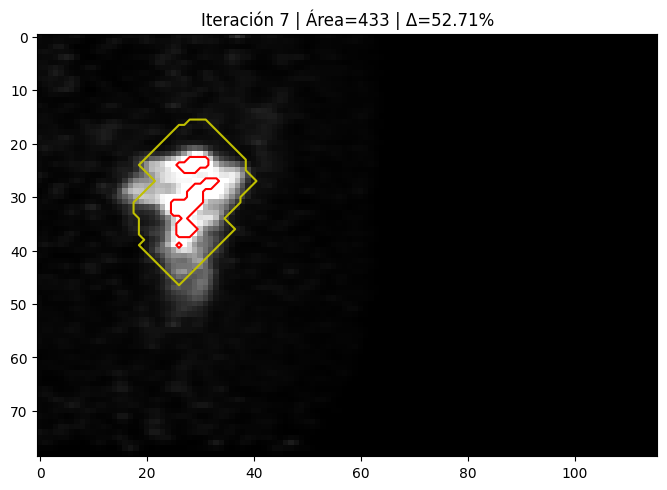

Iteración  8 | Área =  501 | Mean =    6616.28 | Delta =  57.24%


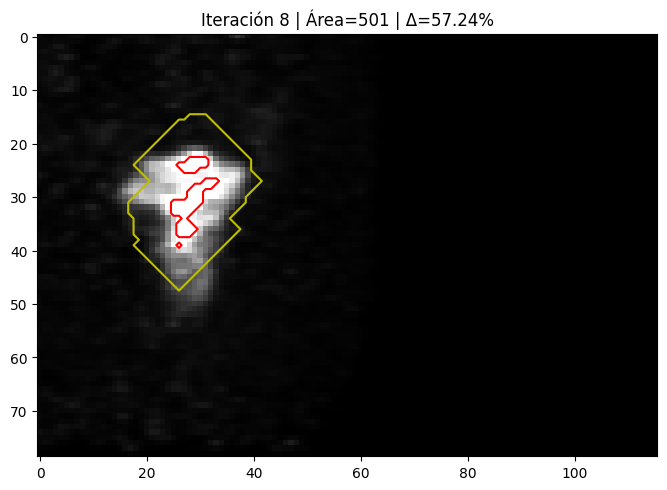

Iteración  9 | Área =  573 | Mean =    5998.88 | Delta =  61.23%


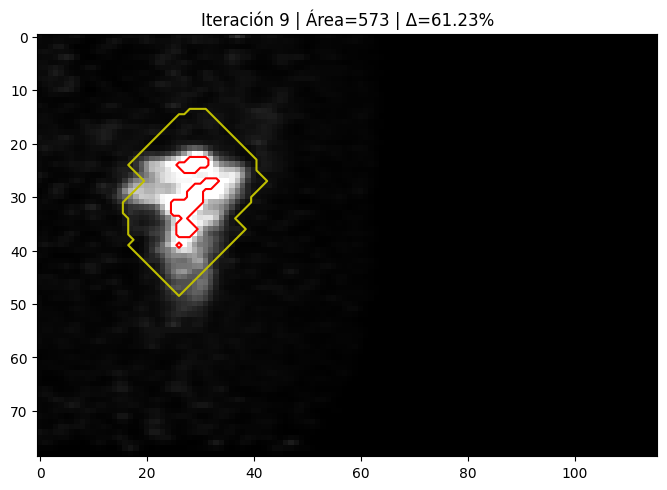

Iteración 10 | Área =  649 | Mean =    5463.37 | Delta =  64.69%


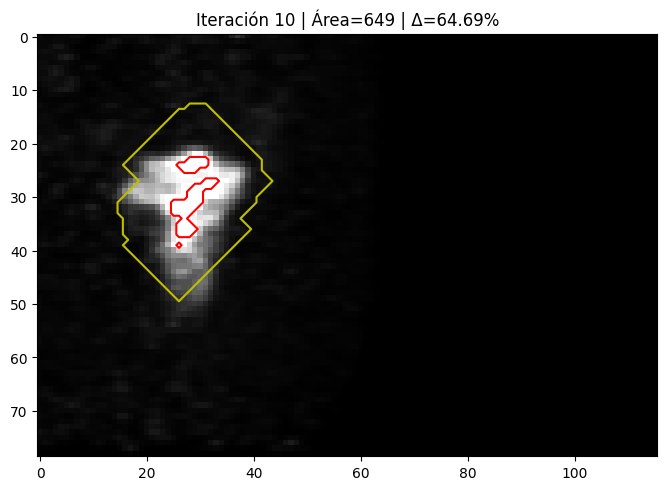

Iteración 11 | Área =  729 | Mean =    5000.36 | Delta =  67.68%


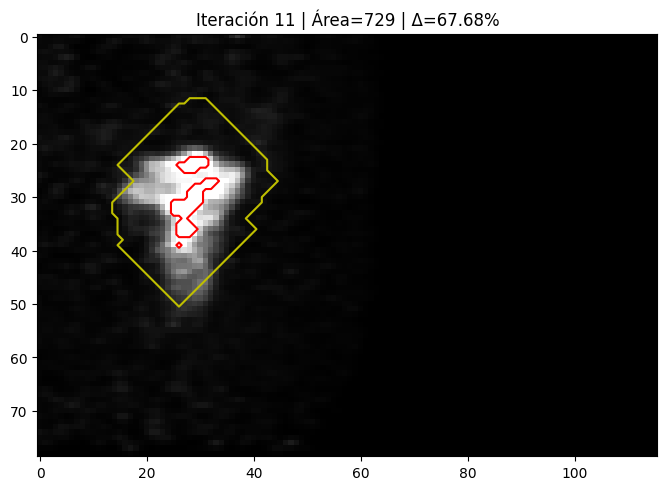

Iteración 12 | Área =  813 | Mean =    4593.55 | Delta =  70.31%


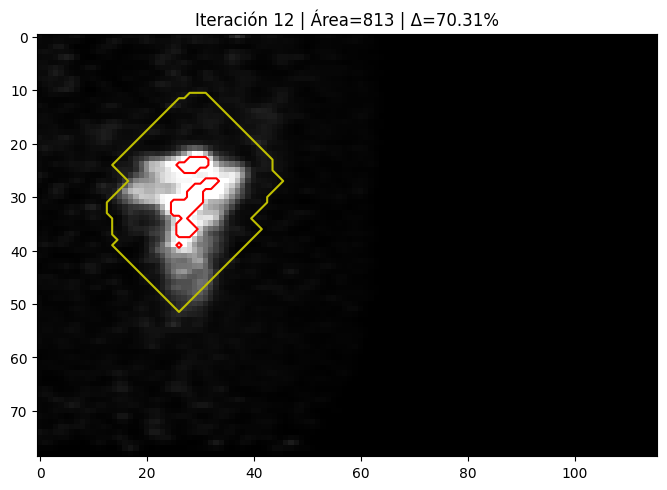

Iteración 13 | Área =  901 | Mean =    4230.23 | Delta =  72.66%


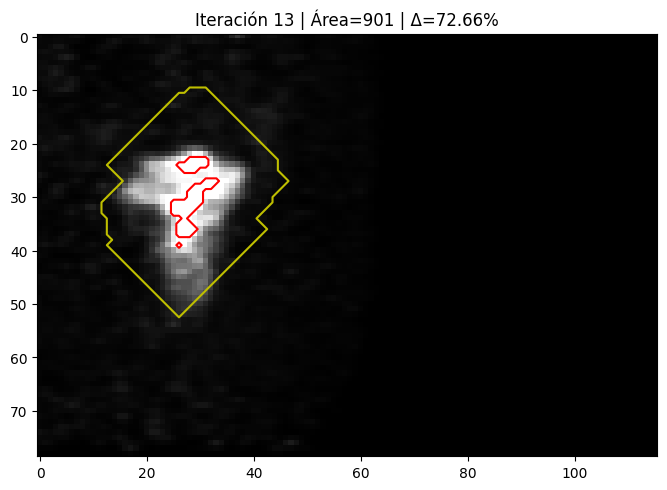

Iteración 14 | Área =  993 | Mean =    3903.63 | Delta =  74.77%


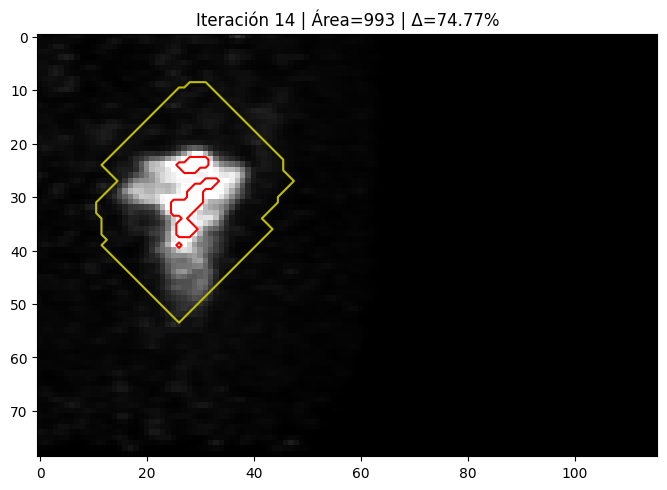

Iteración 15 | Área = 1089 | Mean =    3615.10 | Delta =  76.63%


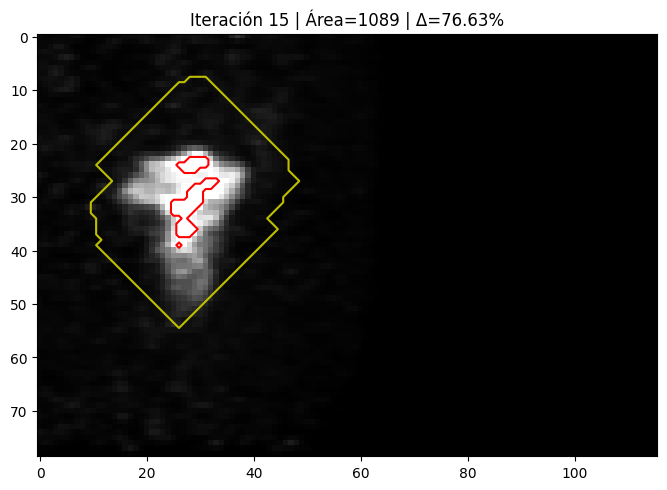

Iteración 16 | Área = 1189 | Mean =    3360.12 | Delta =  78.28%


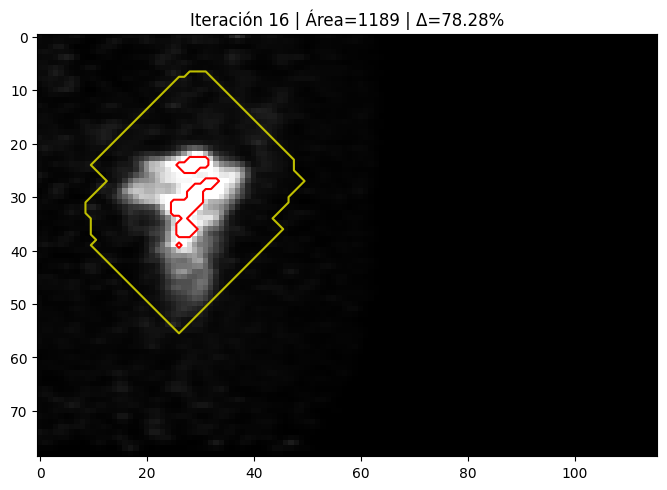

Iteración 17 | Área = 1293 | Mean =    3131.18 | Delta =  79.76%


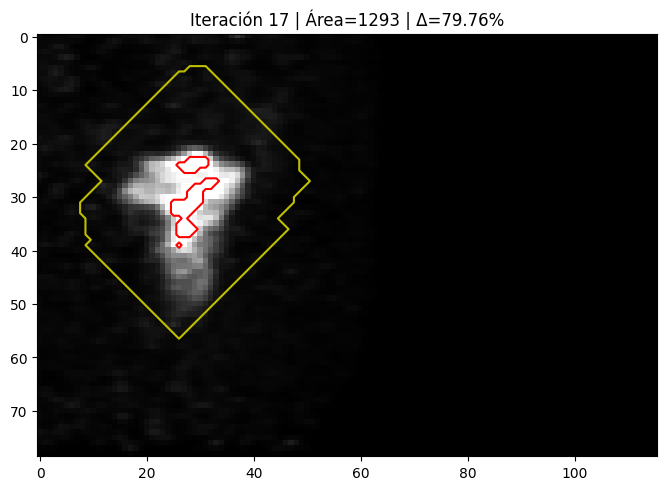

Iteración 18 | Área = 1401 | Mean =    2926.74 | Delta =  81.08%


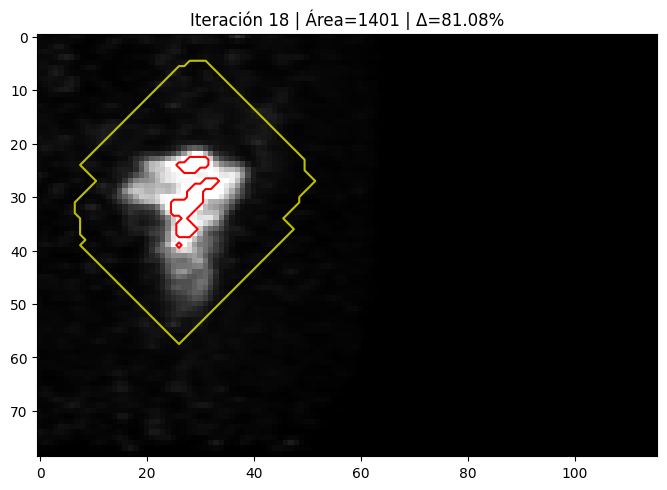

Iteración 19 | Área = 1513 | Mean =    2745.04 | Delta =  82.26%


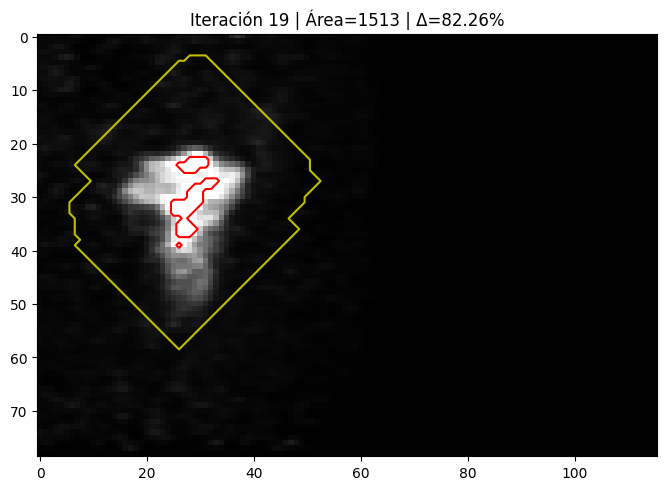

Iteración 20 | Área = 1629 | Mean =    2581.13 | Delta =  83.32%


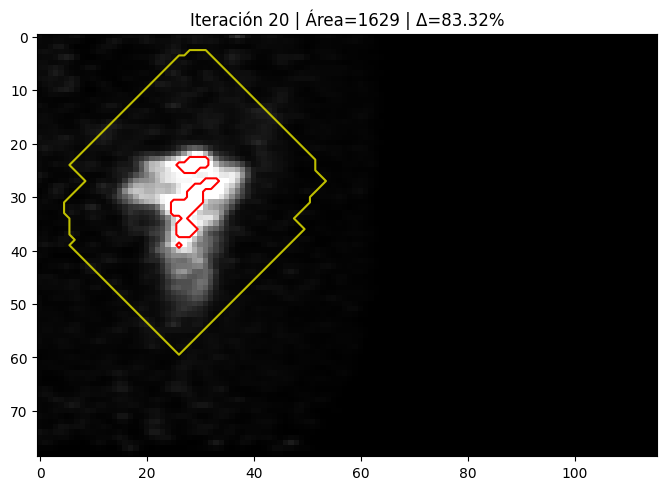

In [22]:
from scipy.ndimage import binary_dilation
import SimpleITK as sitk
import pandas as pd

mask_n = mask0.copy()

resultados = []

for n in range(21):

    # Convertir máscara a SimpleITK
    sitk_mask = sitk.GetImageFromArray(
        mask_n.astype(np.uint8)
    )

    # Radiomía
    result = extractor.execute(
        sitk_img,
        sitk_mask
    )

    mean_n = result["original_firstorder_Mean"]

    delta = abs(mean_n - mean0) / mean0

    area = mask_n.sum()

    resultados.append([
        n,
        area,
        mean_n,
        delta
    ])

    print(
        f"Iteración {n:2d} | "
        f"Área = {area:4d} | "
        f"Mean = {mean_n:10.2f} | "
        f"Delta = {100*delta:6.2f}%"
    )

    # Visualización
    plt.figure(figsize=(8,8))

    plt.imshow(
        roi_img,
        cmap="gray",
        vmin=0,
        vmax=np.percentile(roi_img,99)
    )

    plt.contour(mask0, colors='r')
    plt.contour(mask_n, colors='y')

    plt.title(
        f"Iteración {n} | "
        f"Área={area} | "
        f"Δ={100*delta:.2f}%"
    )

    plt.show()

    # Preparar siguiente iteración
    mask_n = binary_dilation(mask_n)

Entropy ROI0 = 5.501505
Iteración  0 | Área =   53 | Entropy =   5.5015 | Delta =   0.00%


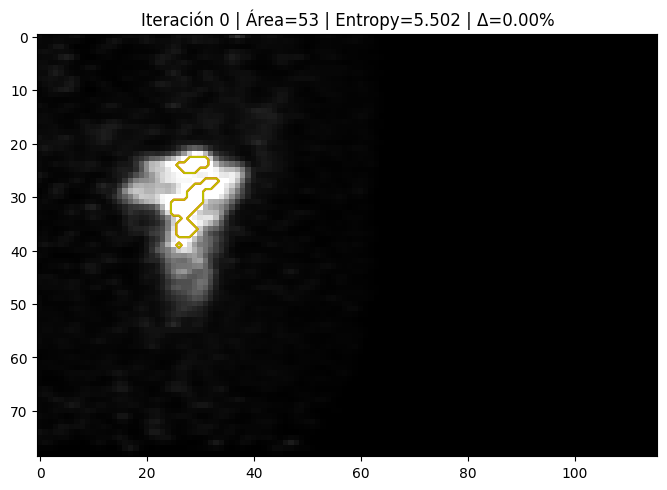

Iteración  1 | Área =  104 | Entropy =   6.3927 | Delta =  16.20%


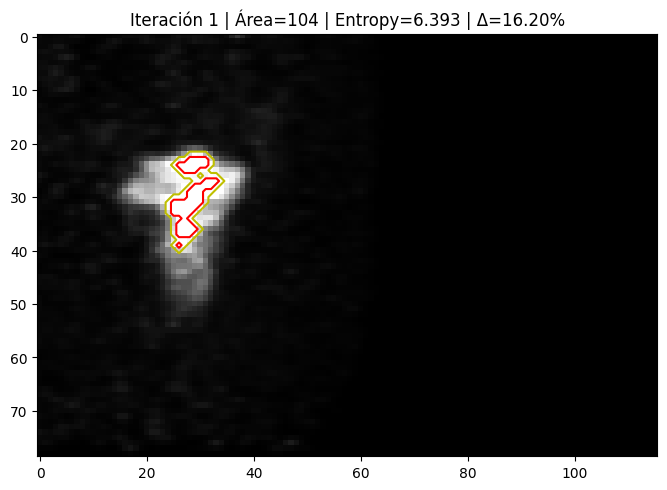

Iteración  2 | Área =  152 | Entropy =   6.9716 | Delta =  26.72%


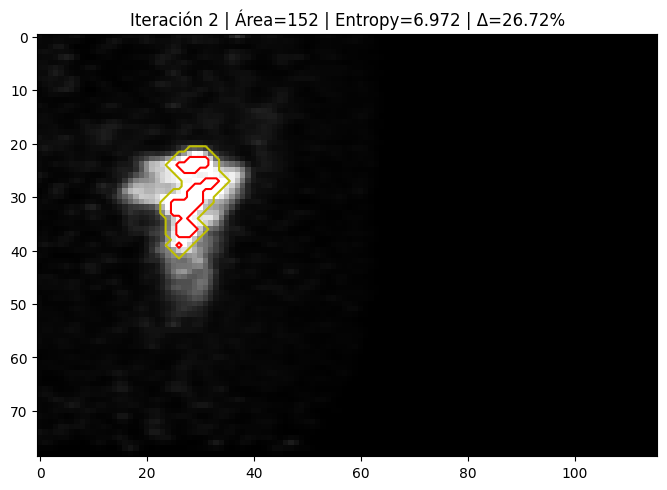

Iteración  3 | Área =  201 | Entropy =   7.3824 | Delta =  34.19%


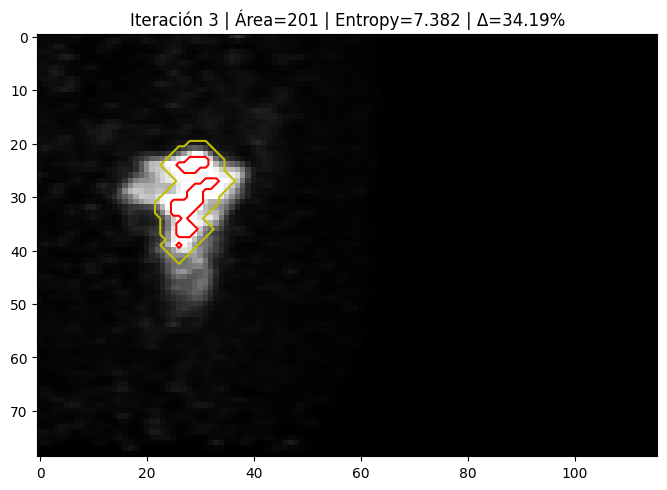

Iteración  4 | Área =  253 | Entropy =   7.6262 | Delta =  38.62%


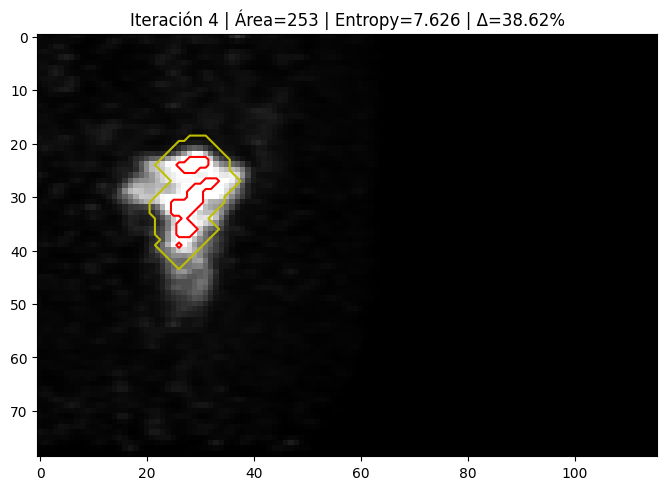

Iteración  5 | Área =  309 | Entropy =   7.8450 | Delta =  42.60%


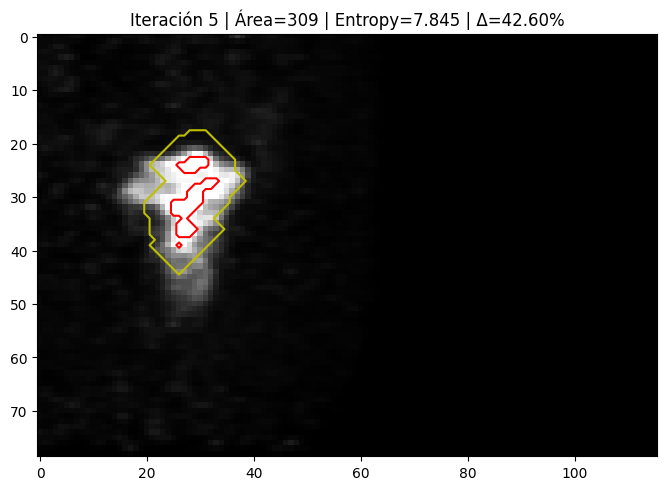

Iteración  6 | Área =  369 | Entropy =   7.9681 | Delta =  44.84%


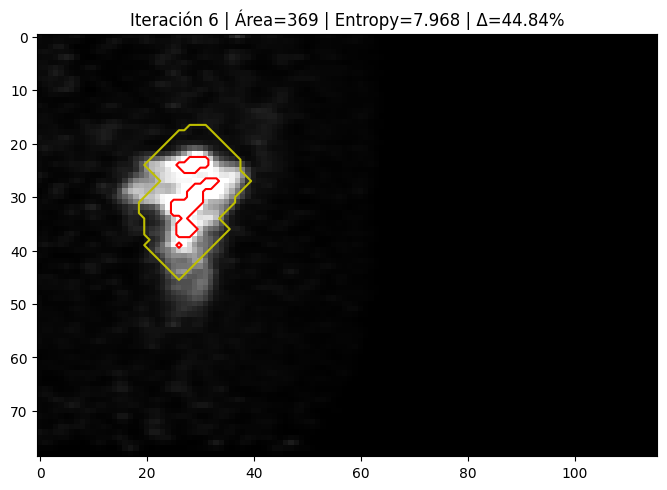

Iteración  7 | Área =  433 | Entropy =   8.1152 | Delta =  47.51%


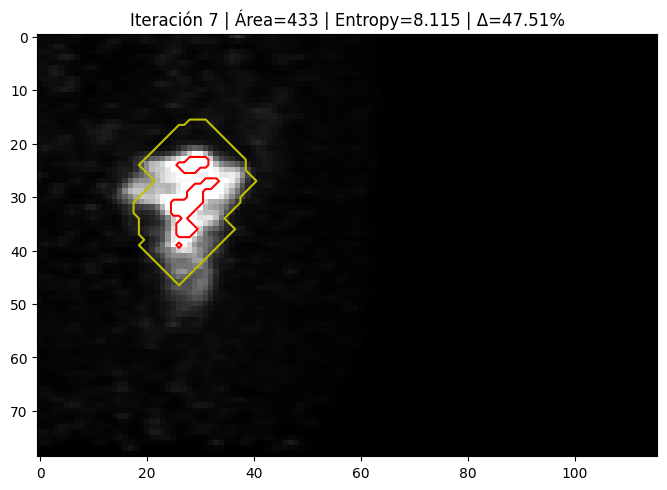

Iteración  8 | Área =  501 | Entropy =   8.1856 | Delta =  48.79%


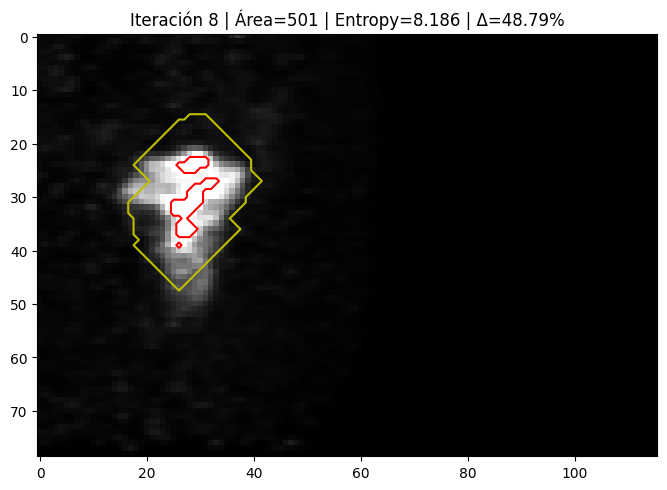

Iteración  9 | Área =  573 | Entropy =   8.1917 | Delta =  48.90%


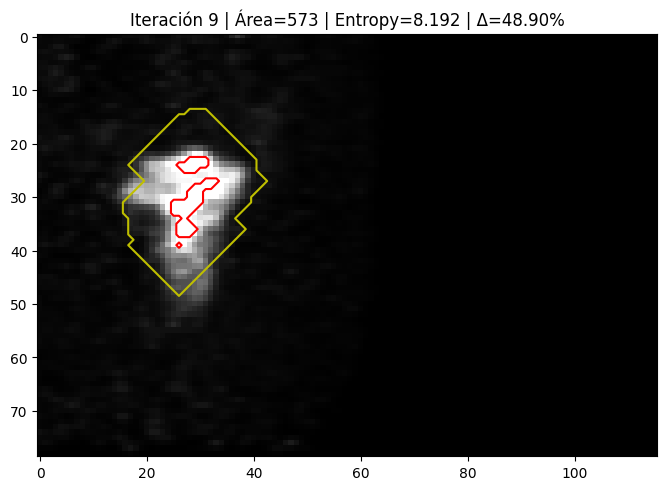

Iteración 10 | Área =  649 | Entropy =   8.1506 | Delta =  48.15%


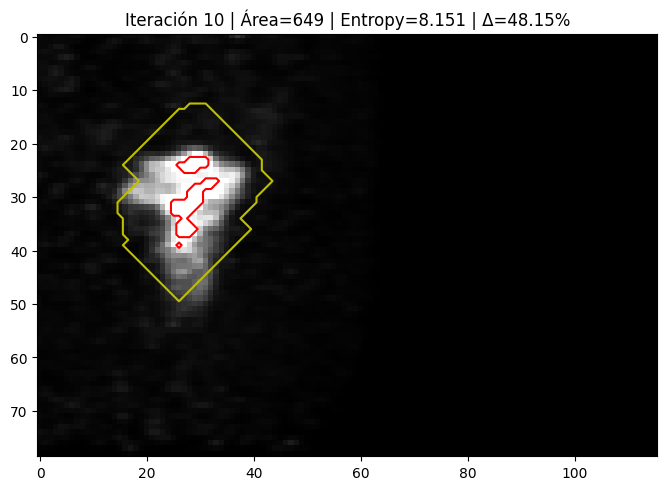

Iteración 11 | Área =  729 | Entropy =   8.0601 | Delta =  46.51%


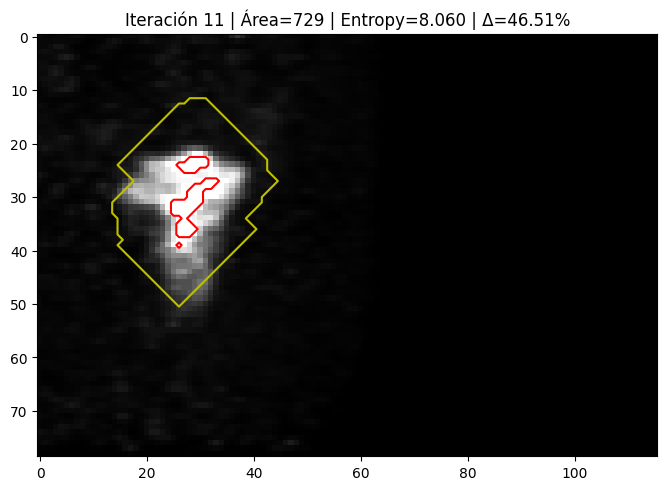

Iteración 12 | Área =  813 | Entropy =   7.9887 | Delta =  45.21%


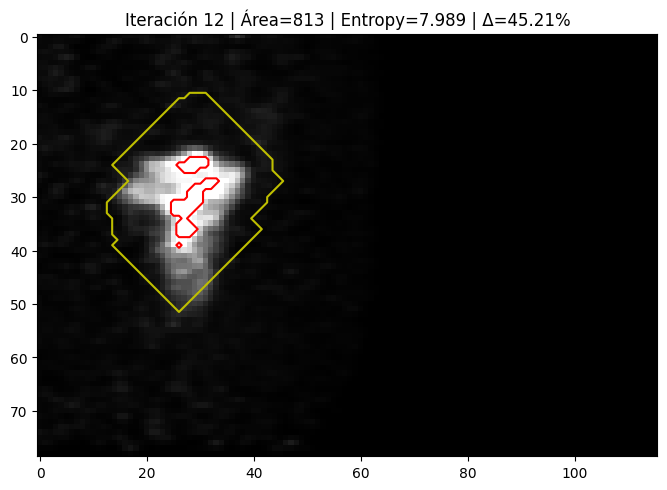

Iteración 13 | Área =  901 | Entropy =   7.8897 | Delta =  43.41%


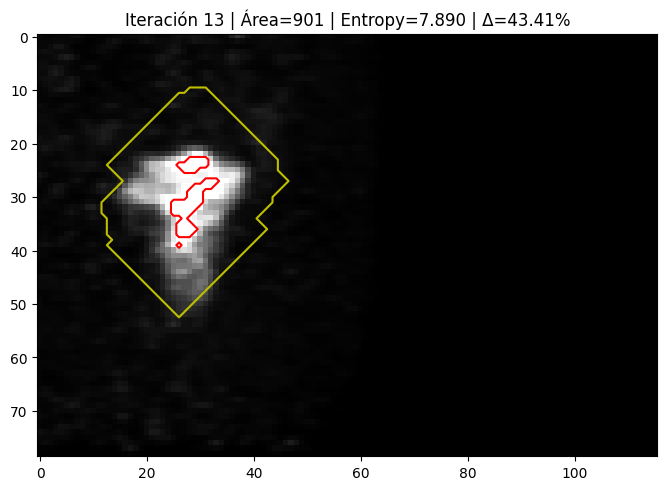

Iteración 14 | Área =  993 | Entropy =   7.7741 | Delta =  41.31%


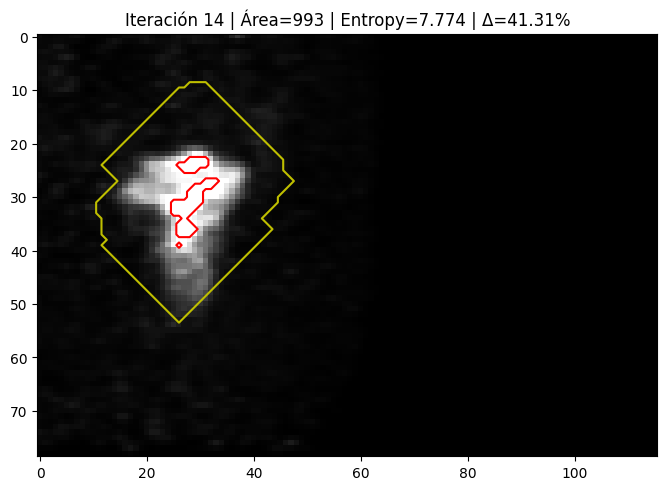

Iteración 15 | Área = 1089 | Entropy =   7.6679 | Delta =  39.38%


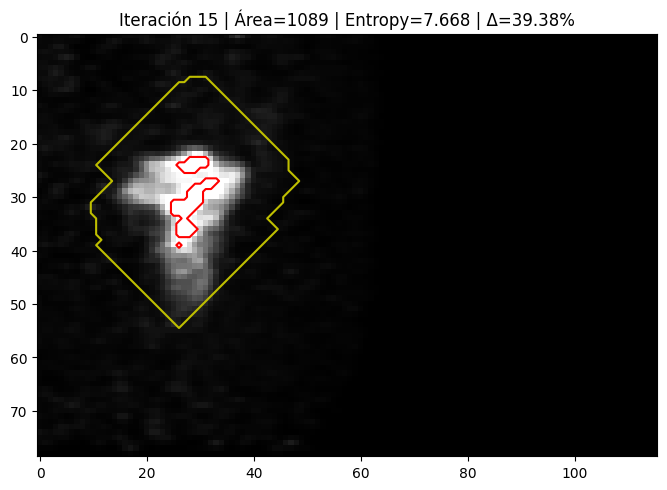

Iteración 16 | Área = 1189 | Entropy =   7.5650 | Delta =  37.51%


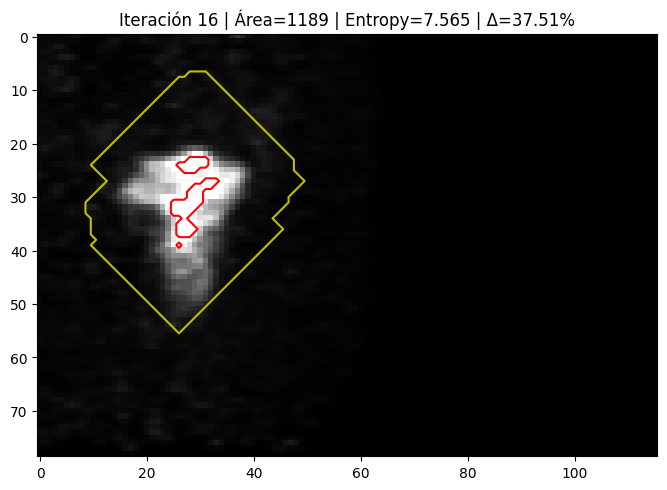

Iteración 17 | Área = 1293 | Entropy =   7.4544 | Delta =  35.50%


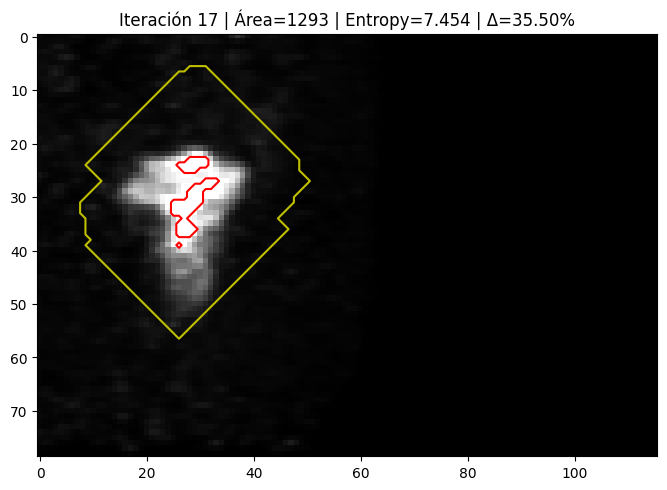

Iteración 18 | Área = 1401 | Entropy =   7.3521 | Delta =  33.64%


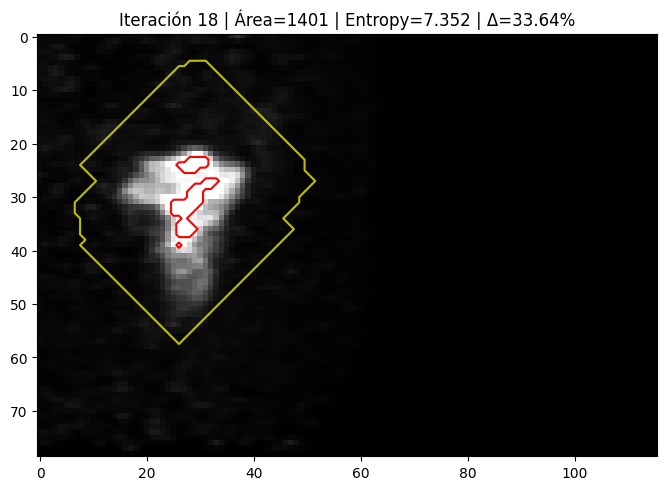

Iteración 19 | Área = 1513 | Entropy =   7.2540 | Delta =  31.86%


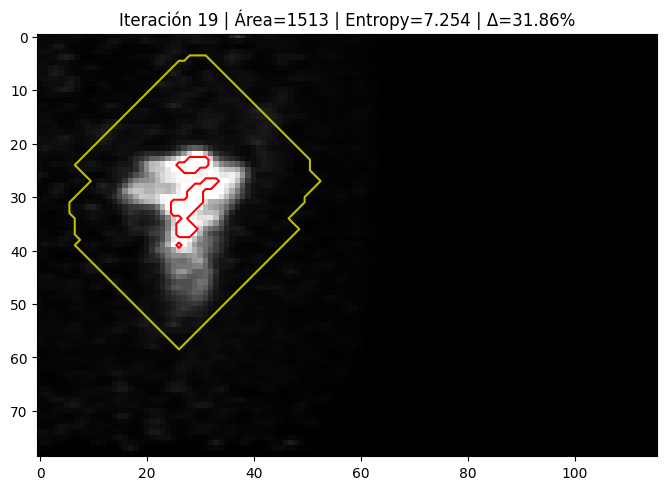

Iteración 20 | Área = 1629 | Entropy =   7.1540 | Delta =  30.04%


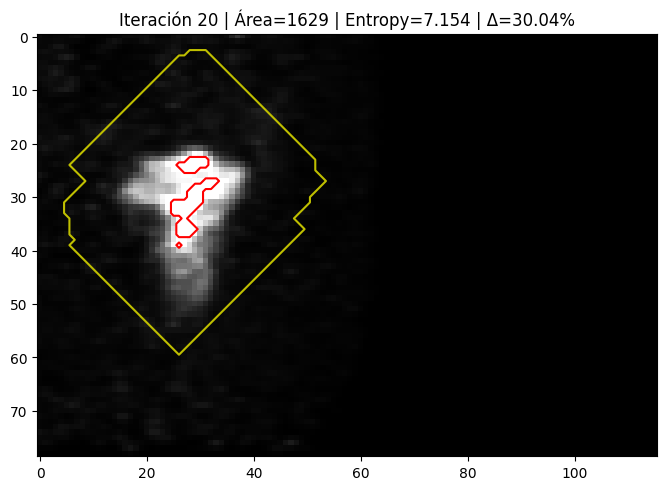

    Iteracion  Area             Entropy     Delta
0           0    53   5.501505360223562  0.000000
1           1   104   6.392747410448756  0.162000
2           2   152    6.97161172396986  0.267219
3           3   201  7.3823949747609605  0.341886
4           4   253   7.626216252534203  0.386205
5           5   309   7.845008537578022  0.425975
6           6   369   7.968117580602565  0.448352
7           7   433   8.115168415624511  0.475081
8           8   501    8.18556690612295  0.487878
9           9   573   8.191674723394804  0.488988
10         10   649   8.150555411615096  0.481514
11         11   729    8.06011142960919  0.465074
12         12   813   7.988673928150065  0.452089
13         13   901   7.889680198104582  0.434095
14         14   993   7.774133511662843  0.413092
15         15  1089   7.667896495824026  0.393782
16         16  1189   7.564951003076796  0.375069
17         17  1293   7.454381963112821  0.354971
18         18  1401   7.352054744228182  0.336371


In [23]:
from scipy.ndimage import binary_dilation
import SimpleITK as sitk
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# Entropía de referencia (ROI0)
# ==========================================

sitk_mask0 = sitk.GetImageFromArray(
    mask0.astype(np.uint8)
)

result0 = extractor.execute(
    sitk_img,
    sitk_mask0
)

entropy0 = result0["original_firstorder_Entropy"]

print(f"Entropy ROI0 = {entropy0:.6f}")

# ==========================================
# Iteraciones
# ==========================================

mask_n = mask0.copy()

resultados = []

for n in range(21):

    # Convertir máscara a SimpleITK
    sitk_mask = sitk.GetImageFromArray(
        mask_n.astype(np.uint8)
    )

    # Radiomía
    result = extractor.execute(
        sitk_img,
        sitk_mask
    )

    entropy_n = result["original_firstorder_Entropy"]

    delta = abs(entropy_n - entropy0) / abs(entropy0)

    area = mask_n.sum()

    resultados.append([
        n,
        area,
        entropy_n,
        delta
    ])

    print(
        f"Iteración {n:2d} | "
        f"Área = {area:4d} | "
        f"Entropy = {entropy_n:8.4f} | "
        f"Delta = {100*delta:6.2f}%"
    )

    # Visualización
    plt.figure(figsize=(8,8))

    plt.imshow(
        roi_img,
        cmap="gray",
        vmin=0,
        vmax=np.percentile(roi_img,99)
    )

    plt.contour(mask0, colors='r')
    plt.contour(mask_n, colors='y')

    plt.title(
        f"Iteración {n} | "
        f"Área={area} | "
        f"Entropy={entropy_n:.3f} | "
        f"Δ={100*delta:.2f}%"
    )

    plt.show()

    # Preparar siguiente iteración
    mask_n = binary_dilation(mask_n)

# ==========================================
# Tabla final
# ==========================================

df = pd.DataFrame(
    resultados,
    columns=[
        "Iteracion",
        "Area",
        "Entropy",
        "Delta"
    ]
)

print(df)

In [24]:
df = pd.DataFrame(
    resultados,
    columns=[
        "Iteracion",
        "Area",
        "Mean",
        "Delta"
    ]
)

print(df)

    Iteracion  Area                Mean     Delta
0           0    53   5.501505360223562  0.000000
1           1   104   6.392747410448756  0.162000
2           2   152    6.97161172396986  0.267219
3           3   201  7.3823949747609605  0.341886
4           4   253   7.626216252534203  0.386205
5           5   309   7.845008537578022  0.425975
6           6   369   7.968117580602565  0.448352
7           7   433   8.115168415624511  0.475081
8           8   501    8.18556690612295  0.487878
9           9   573   8.191674723394804  0.488988
10         10   649   8.150555411615096  0.481514
11         11   729    8.06011142960919  0.465074
12         12   813   7.988673928150065  0.452089
13         13   901   7.889680198104582  0.434095
14         14   993   7.774133511662843  0.413092
15         15  1089   7.667896495824026  0.393782
16         16  1189   7.564951003076796  0.375069
17         17  1293   7.454381963112821  0.354971
18         18  1401   7.352054744228182  0.336371


### Voxel based

In [25]:
from radiomics import featureextractor

extractor_voxel = featureextractor.RadiomicsFeatureExtractor()

extractor_voxel.disableAllFeatures()

extractor_voxel.enableFeaturesByName(
    firstorder=['Entropy']
)

print("Extractor creado")

Extractor creado


In [26]:
print(extractor_voxel.enabledFeatures)

{'firstorder': ['Entropy']}


In [27]:
extractor_voxel.settings['kernelRadius'] = 1

print(extractor_voxel.settings['kernelRadius'])

1


In [28]:
roi_img_3d = roi_img[np.newaxis, :, :]
mask0_3d = mask0[np.newaxis, :, :]

print(roi_img_3d.shape)
print(mask0_3d.shape)

(1, 79, 116)
(1, 79, 116)


In [29]:
sitk_img_3d = sitk.GetImageFromArray(
    roi_img_3d.astype(np.float32)
)

sitk_mask_3d = sitk.GetImageFromArray(
    mask0_3d.astype(np.uint8)
)

print("Imagen:", sitk_img_3d.GetSize())
print("Mascara:", sitk_mask_3d.GetSize())

Imagen: (116, 79, 1)
Mascara: (116, 79, 1)


#### Extrayendo

In [30]:
extractor_voxel.settings['force2D'] = True
extractor_voxel.settings['force2Ddimension'] = 0

print(extractor_voxel.settings['force2D'])
print(extractor_voxel.settings['force2Ddimension'])

True
0


In [31]:
print("Imagen:", sitk_img_3d.GetSize())
print("Mascara:", sitk_mask_3d.GetSize())

Imagen: (116, 79, 1)
Mascara: (116, 79, 1)


In [32]:
result_voxel = extractor_voxel.execute(
    sitk_img_3d,
    sitk_mask_3d,
    voxelBased=True
)

print("Ejecutado correctamente")

for k in result_voxel.keys():
    print(k)

Ejecutado correctamente
diagnostics_Versions_PyRadiomics
diagnostics_Versions_Numpy
diagnostics_Versions_SimpleITK
diagnostics_Versions_PyWavelet
diagnostics_Versions_Python
diagnostics_Configuration_Settings
diagnostics_Configuration_EnabledImageTypes
diagnostics_Image-original_Hash
diagnostics_Image-original_Dimensionality
diagnostics_Image-original_Spacing
diagnostics_Image-original_Size
diagnostics_Image-original_Mean
diagnostics_Image-original_Minimum
diagnostics_Image-original_Maximum
diagnostics_Mask-original_Hash
diagnostics_Mask-original_Spacing
diagnostics_Mask-original_Size
diagnostics_Mask-original_BoundingBox
diagnostics_Mask-original_VoxelNum
diagnostics_Mask-original_VolumeNum
diagnostics_Mask-original_CenterOfMassIndex
diagnostics_Mask-original_CenterOfMass
original_firstorder_Entropy


In [33]:
entropy_img = result_voxel[
    "original_firstorder_Entropy"
]

print(type(entropy_img))

<class 'SimpleITK.SimpleITK.Image'>


In [34]:
entropy_map = sitk.GetArrayFromImage(
    entropy_img
)

print(entropy_map.shape)

print(
    np.nanmin(entropy_map),
    np.nanmax(entropy_map)
)

(1, 19, 11)
-3.203426503814917e-16 3.1699250014423086


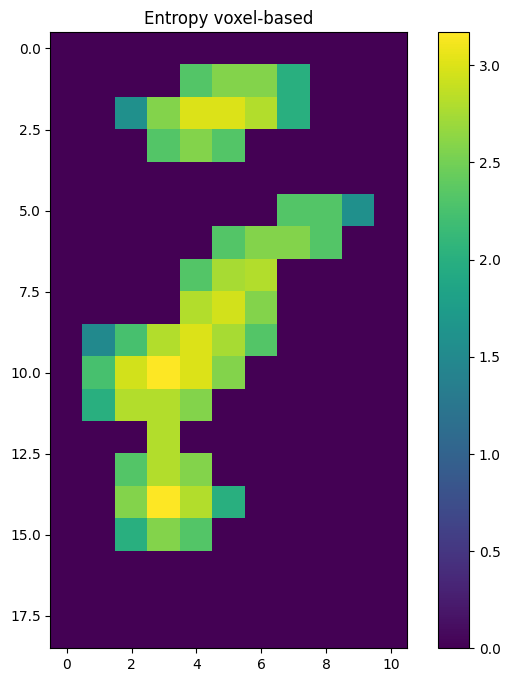

In [35]:
entropy_2d = entropy_map[0]

plt.figure(figsize=(8,8))

plt.imshow(entropy_2d)

plt.colorbar()

plt.title("Entropy voxel-based")
plt.show()

In [36]:
vals_roi0 = entropy_2d[entropy_2d > 0]

print("Número de voxeles:", len(vals_roi0))
print("Media:", vals_roi0.mean())
print("Std:", vals_roi0.std())

print(
    "Percentiles:",
    np.percentile(
        vals_roi0,
        [5, 25, 50, 75, 95]
    )
)

Número de voxeles: 52
Media: 2.5141421586245376
Std: 0.38597206251389926
Percentiles: [1.81323313 2.32192809 2.5849625  2.80735492 3.        ]


In [37]:
print("Area ROI0:", mask0.sum())

print(
    "Voxeles Entropy > 0:",
    np.sum(entropy_2d > 0)
)

print(
    "Voxeles Entropy == 0:",
    np.sum(entropy_2d == 0)
)

Area ROI0: 53
Voxeles Entropy > 0: 52
Voxeles Entropy == 0: 156


In [38]:
corona1 = mask1 & (~mask0)

print("Pixeles corona1:", corona1.sum())

Pixeles corona1: 51


In [39]:
mask1_3d = mask1[np.newaxis, :, :]

sitk_mask1_3d = sitk.GetImageFromArray(
    mask1_3d.astype(np.uint8)
)

In [40]:
result_mask1 = extractor_voxel.execute(
    sitk_img_3d,
    sitk_mask1_3d,
    voxelBased=True
)

print("OK")

OK


In [41]:
entropy_img1 = result_mask1[
    "original_firstorder_Entropy"
]

entropy_map1 = sitk.GetArrayFromImage(
    entropy_img1
)

print(entropy_map1.shape)
print(np.nanmin(entropy_map1))
print(np.nanmax(entropy_map1))

(1, 21, 13)
0.0
3.1699250014423095


In [42]:
entropy_map1.shape

(1, 21, 13)

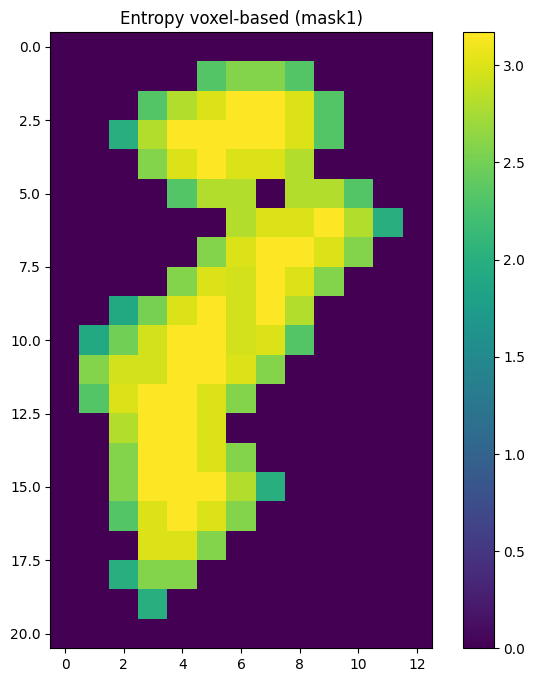

In [43]:
entropy1_2d = entropy_map1[0]

plt.figure(figsize=(8,8))

plt.imshow(entropy1_2d)
plt.colorbar()

plt.title("Entropy voxel-based (mask1)")
plt.show()

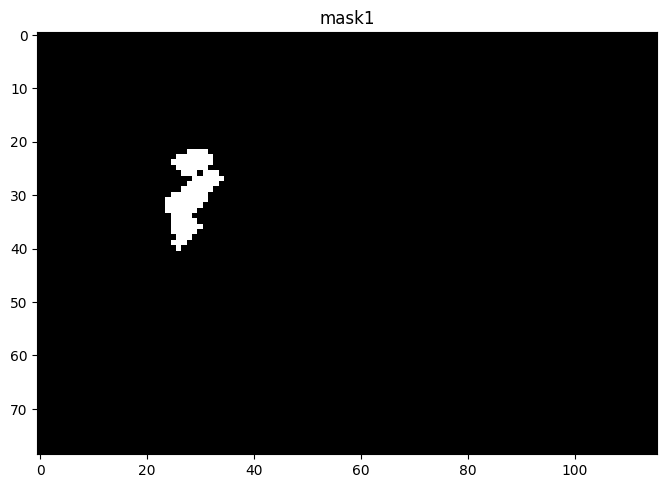

In [44]:
plt.figure(figsize=(8,8))

plt.imshow(mask1, cmap="gray")

plt.title("mask1")
plt.show()

In [45]:
print(
    result_mask1[
        "diagnostics_Mask-original_BoundingBox"
    ]
)

(24, 22, 0, 11, 19, 1)


#### _____________________________________________________________________________________

In [46]:
sitk_corona1 = sitk.GetImageFromArray(
    corona1.astype(np.uint8)
)

print("Pixeles corona1:", corona1.sum())

from radiomics import featureextractor

extractor_entropy = featureextractor.RadiomicsFeatureExtractor()

extractor_entropy.disableAllFeatures()

extractor_entropy.enableFeaturesByName(
    firstorder=['Entropy']
)

result_corona1 = extractor_entropy.execute(
    sitk_img,
    sitk_corona1
)

entropy_corona1 = result_corona1[
    "original_firstorder_Entropy"
]

print("Entropy Corona1 =", entropy_corona1)

Pixeles corona1: 51
Entropy Corona1 = 5.2802684792263825


Corona  1 | Pixeles =   51 | Entropy = 5.2803


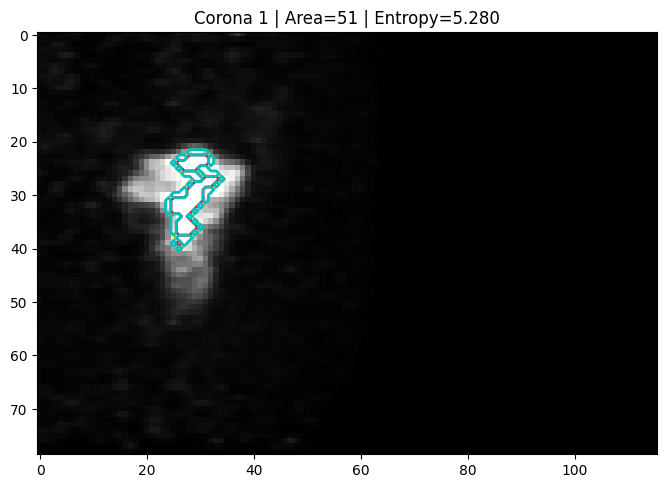

Corona  2 | Pixeles =   48 | Entropy = 5.5433


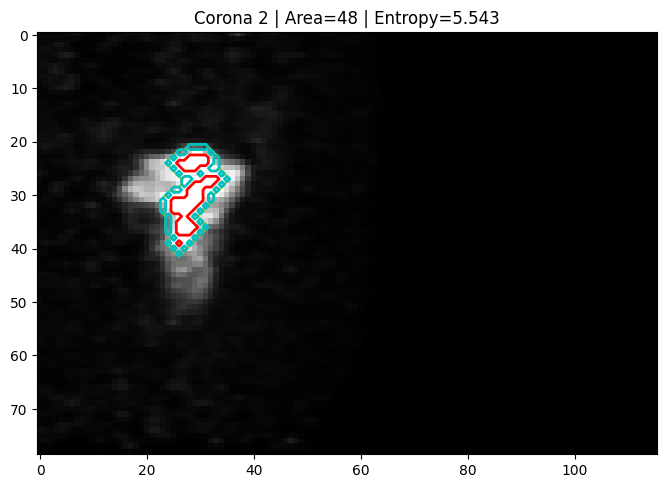

Corona  3 | Pixeles =   49 | Entropy = 5.4923


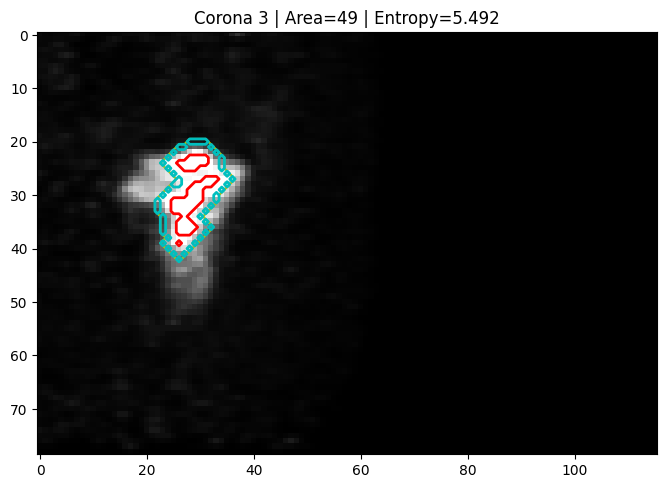

Corona  4 | Pixeles =   52 | Entropy = 5.4552


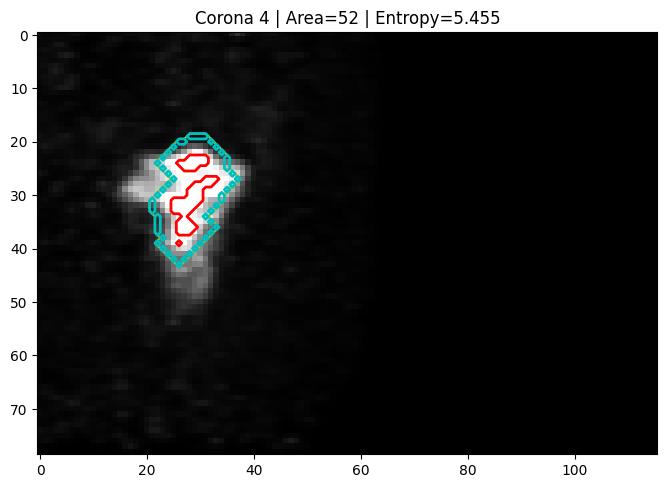

Corona  5 | Pixeles =   56 | Entropy = 5.6645


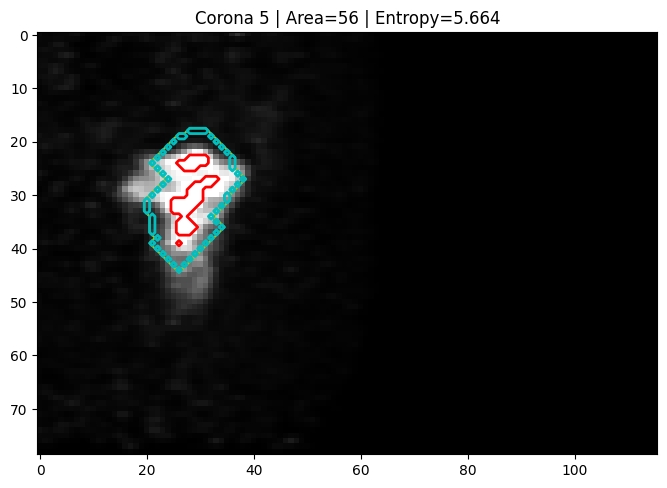

Corona  6 | Pixeles =   60 | Entropy = 5.6276


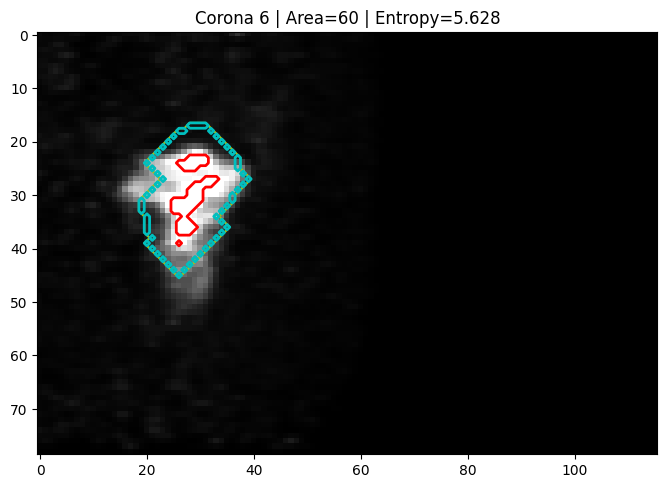

Corona  7 | Pixeles =   64 | Entropy = 5.8750


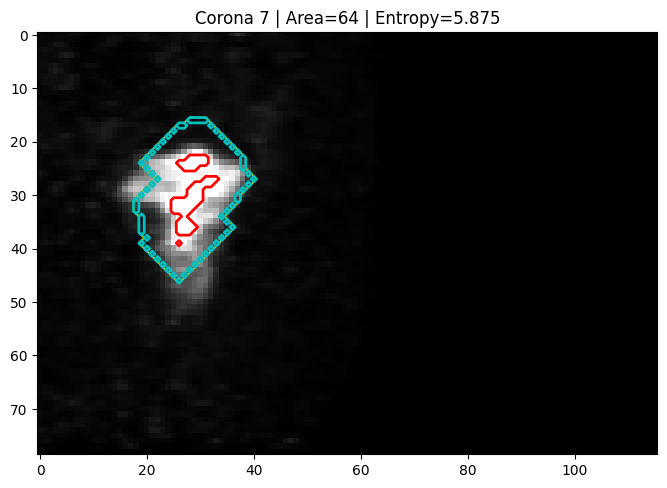

Corona  8 | Pixeles =   68 | Entropy = 5.6313


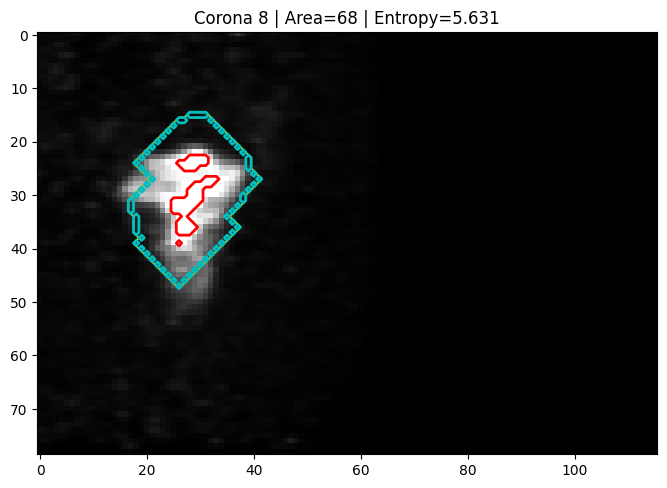

Corona  9 | Pixeles =   72 | Entropy = 5.5551


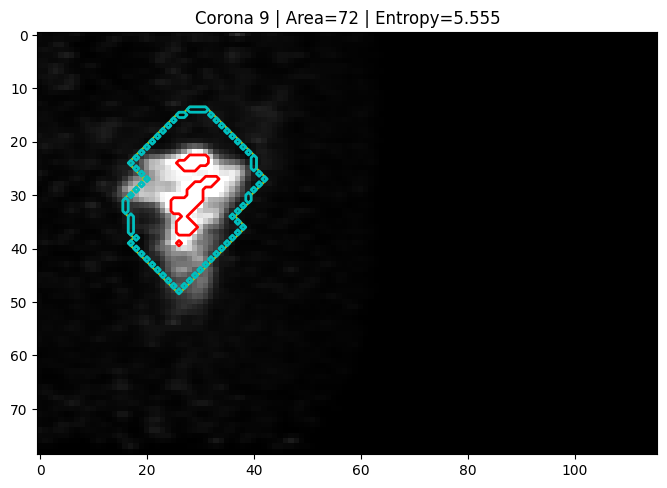

Corona 10 | Pixeles =   76 | Entropy = 5.3280


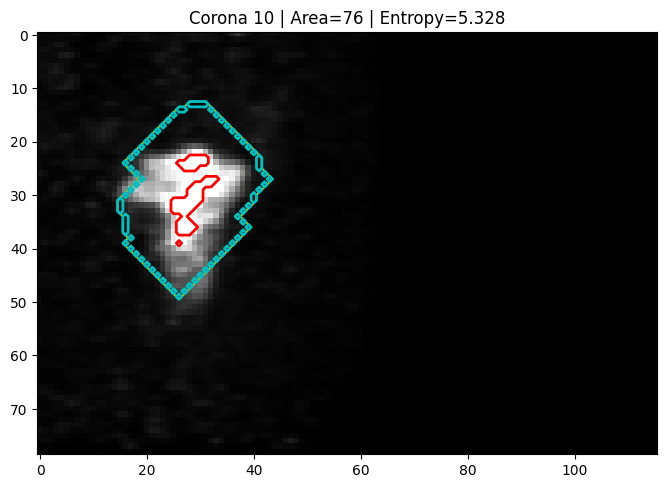

Corona 11 | Pixeles =   80 | Entropy = 5.3197


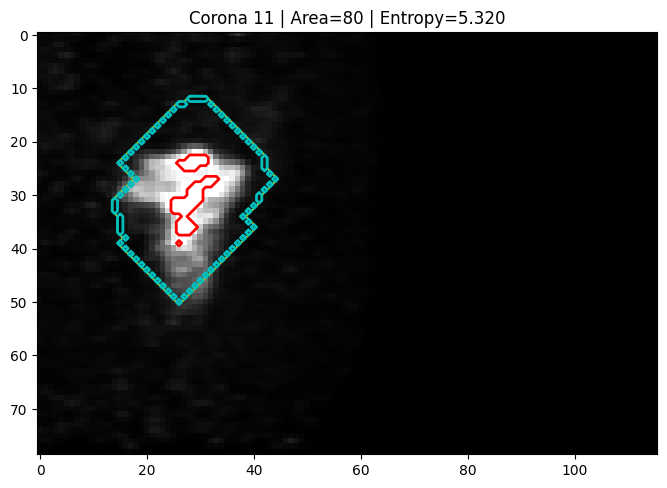

Corona 12 | Pixeles =   84 | Entropy = 5.4101


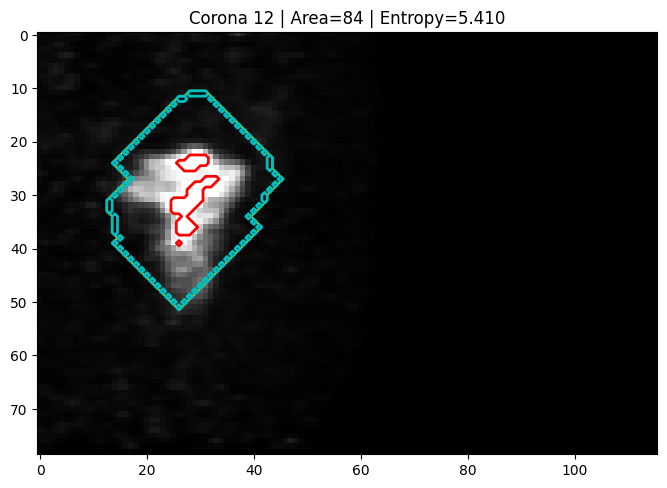

Corona 13 | Pixeles =   88 | Entropy = 5.3076


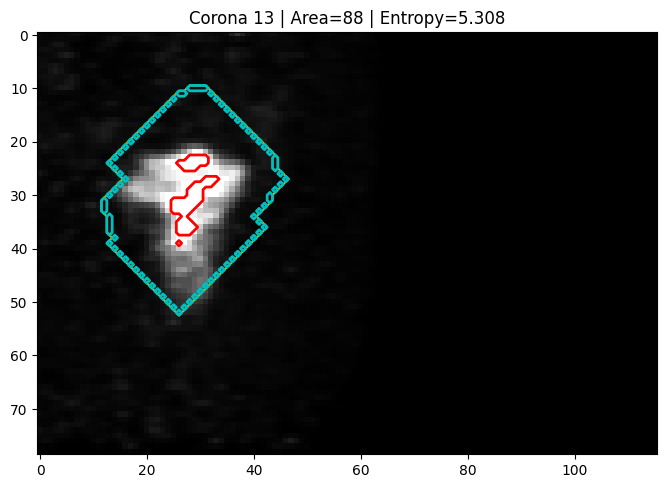

Corona 14 | Pixeles =   92 | Entropy = 5.0616


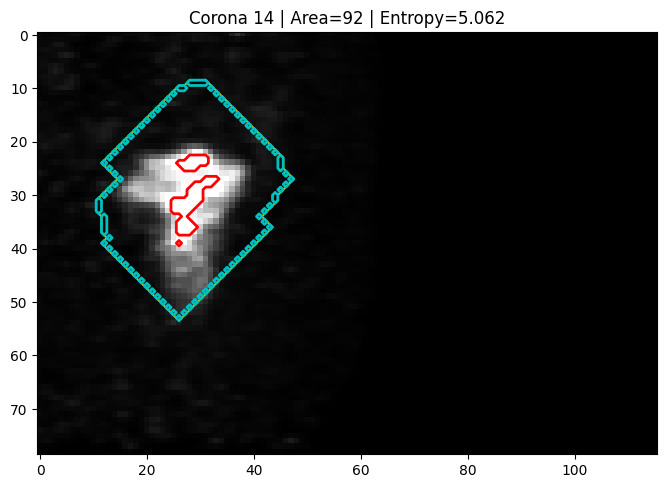

Corona 15 | Pixeles =   96 | Entropy = 5.0999


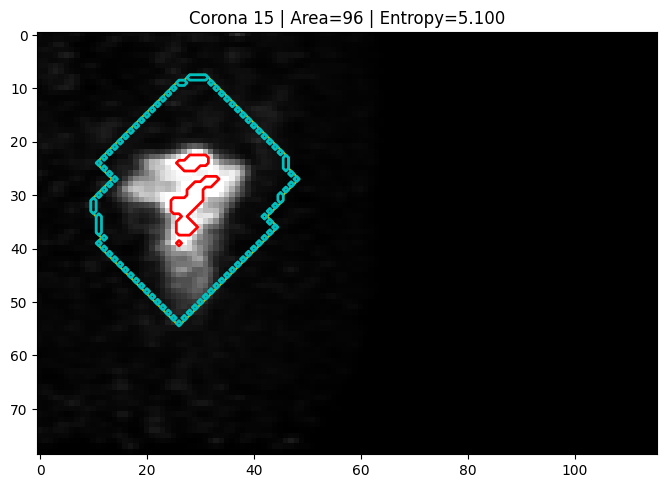

Corona 16 | Pixeles =  100 | Entropy = 5.1456


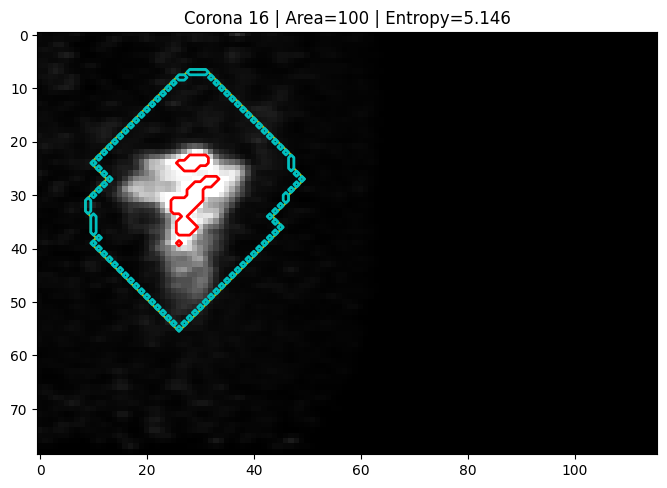

Corona 17 | Pixeles =  104 | Entropy = 5.0861


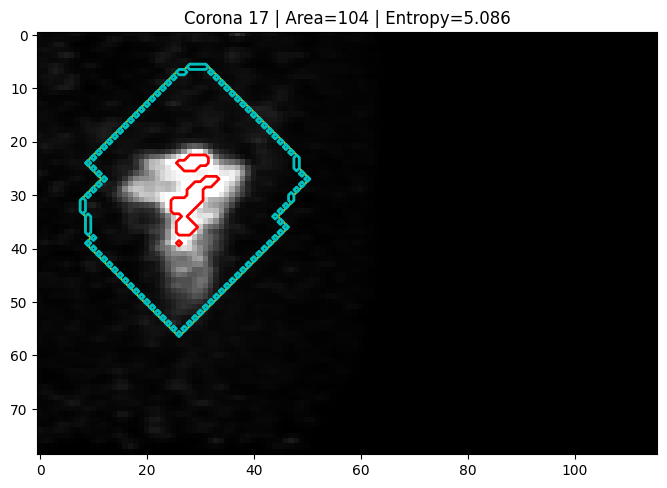

Corona 18 | Pixeles =  108 | Entropy = 4.8739


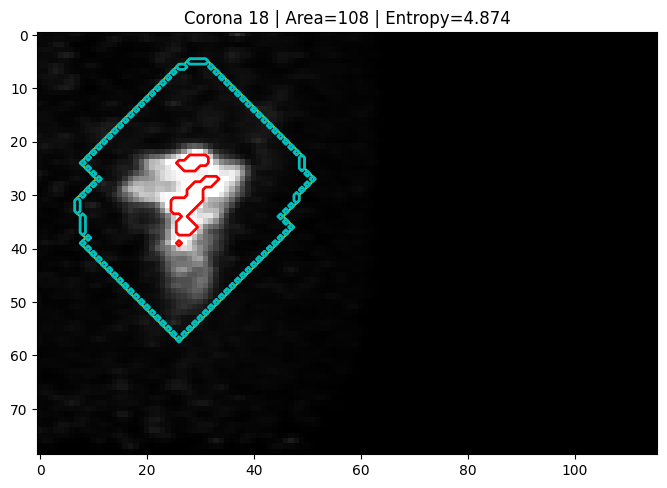

Corona 19 | Pixeles =  112 | Entropy = 4.7898


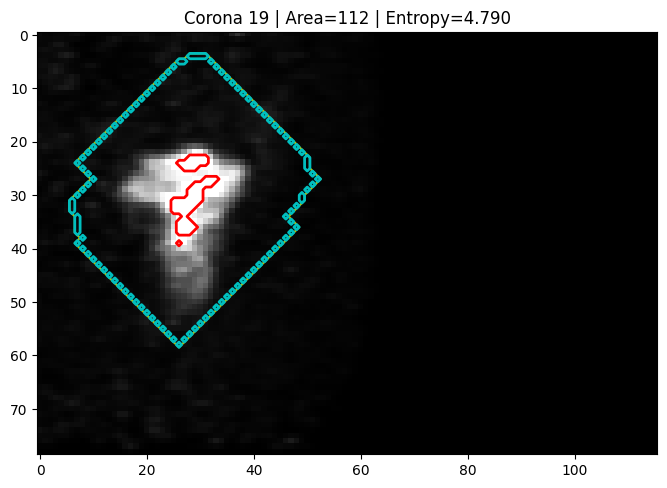

    Corona  Area             Entropy
0        1    51  5.2802684792263825
1        2    48   5.543295834054474
2        3    49   5.492260864523358
3        4    52   5.455153420022548
4        5    56   5.664497779200442
5        6    60   5.627642470572445
6        7    64   5.874999999999982
7        8    68   5.631292988181881
8        9    72   5.555138022185483
9       10    76   5.327978211326549
10      11    80  5.3196679765450465
11      12    84   5.410132976778531
12      13    88   5.307633363679424
13      14    92   5.061567461882893
14      15    96   5.099874739988971
15      16   100   5.145629790944696
16      17   104   5.086136146513463
17      18   108   4.873881054217976
18      19   112   4.789816088726542


In [47]:
from scipy.ndimage import binary_dilation
import pandas as pd
import matplotlib.pyplot as plt
import SimpleITK as sitk

mask_prev = mask0.copy()

resultados_coronas = []

for n in range(1, 20):

    # Dilatación
    mask_next = binary_dilation(mask_prev)

    # Corona actual
    corona = mask_next & (~mask_prev)

    # Máscara SimpleITK
    sitk_corona = sitk.GetImageFromArray(
        corona.astype(np.uint8)
    )

    # Radiomía
    result = extractor_entropy.execute(
        sitk_img,
        sitk_corona
    )

    entropy = result[
        "original_firstorder_Entropy"
    ]

    area = corona.sum()

    resultados_coronas.append([
        n,
        area,
        entropy
    ])

    print(
        f"Corona {n:2d} | "
        f"Pixeles = {area:4d} | "
        f"Entropy = {entropy:.4f}"
    )

    # Visualización
    plt.figure(figsize=(8,8))

    plt.imshow(
        roi_img,
        cmap="gray",
        vmin=0,
        vmax=np.percentile(roi_img,99)
    )

    # ROI inicial
    plt.contour(
        mask0,
        colors='r',
        linewidths=2
    )

    # ROI acumulada actual
    plt.contour(
        mask_next,
        colors='y',
        linewidths=1.5
    )

    # Corona actual
    plt.contour(
        corona,
        colors='c',
        linewidths=2
    )

    plt.title(
        f"Corona {n} | "
        f"Area={area} | "
        f"Entropy={entropy:.3f}"
    )

    plt.show()

    # Actualizar para la siguiente iteración
    mask_prev = mask_next

# Tabla final
df_coronas = pd.DataFrame(
    resultados_coronas,
    columns=[
        "Corona",
        "Area",
        "Entropy"
    ]
)

print(df_coronas)

In [48]:
from radiomics import featureextractor

extractor_multi = featureextractor.RadiomicsFeatureExtractor()

extractor_multi.disableAllFeatures()

extractor_multi.enableFeaturesByName(
    firstorder=[
        'Mean',
        'Median',
        'Entropy',
        'Energy'
    ]
)

In [49]:
from scipy.ndimage import binary_dilation
import pandas as pd
import SimpleITK as sitk

mask_prev = mask0.copy()

resultados = []

for n in range(1, 20):

    mask_next = binary_dilation(mask_prev)

    corona = mask_next & (~mask_prev)

    sitk_corona = sitk.GetImageFromArray(
        corona.astype(np.uint8)
    )

    result = extractor_multi.execute(
        sitk_img,
        sitk_corona
    )

    resultados.append([
        n,
        corona.sum(),
        result["original_firstorder_Mean"],
        result["original_firstorder_Median"],
        result["original_firstorder_Entropy"],
        result["original_firstorder_Energy"]
    ])

    mask_prev = mask_next

df = pd.DataFrame(
    resultados,
    columns=[
        "Corona",
        "Area",
        "Mean",
        "Median",
        "Entropy",
        "Energy"
    ]
)

df

,Corona,Area,Mean,Median,Entropy,Energy
0,1,51,11991.885148590687,12167.544921875,5.2802684792263825,7423784002.858023
1,2,48,9031.24860127767,9238.357421875,5.543295834054474,4300910180.319486
2,3,49,6769.652065977758,6650.8017578125,5.492260864523358,2833996508.905122
3,4,52,5545.682049091046,5406.43994140625,5.455153420022548,2227580393.072421
4,5,56,4756.782172066824,4703.69384765625,5.664497779200442,1865710216.671311
5,6,60,3860.098419189453,3152.5504150390625,5.627642470572445,1386105184.404057
6,7,64,2886.885631084442,1942.439208984375,5.874999999999982,908243677.926609
7,8,68,2159.5494196274703,1366.744140625,5.631292988181881,604210865.6319375
8,9,72,1702.8067395952012,894.8609313964844,5.555138022185483,456300036.6670581
9,10,76,1425.892859810277,792.9148864746094,5.327978211326549,374567466.2353378


#### ___________________________________________________________________________________________

In [50]:
from radiomics import featureextractor

extractor_voxel_med = featureextractor.RadiomicsFeatureExtractor()

extractor_voxel_med.disableAllFeatures()

extractor_voxel_med.enableFeaturesByName(
    firstorder=['Median']
)

In [51]:
result_voxel_med = extractor_voxel_med.execute(
    sitk_img_3d,
    sitk_mask1_3d,
    voxelBased=True
)

print("Ejecutado correctamente")

for k in result_voxel_med.keys():
    print(k)

Ejecutado correctamente
diagnostics_Versions_PyRadiomics
diagnostics_Versions_Numpy
diagnostics_Versions_SimpleITK
diagnostics_Versions_PyWavelet
diagnostics_Versions_Python
diagnostics_Configuration_Settings
diagnostics_Configuration_EnabledImageTypes
diagnostics_Image-original_Hash
diagnostics_Image-original_Dimensionality
diagnostics_Image-original_Spacing
diagnostics_Image-original_Size
diagnostics_Image-original_Mean
diagnostics_Image-original_Minimum
diagnostics_Image-original_Maximum
diagnostics_Mask-original_Hash
diagnostics_Mask-original_Spacing
diagnostics_Mask-original_Size
diagnostics_Mask-original_BoundingBox
diagnostics_Mask-original_VoxelNum
diagnostics_Mask-original_VolumeNum
diagnostics_Mask-original_CenterOfMassIndex
diagnostics_Mask-original_CenterOfMass
original_firstorder_Median


(1, 21, 13)


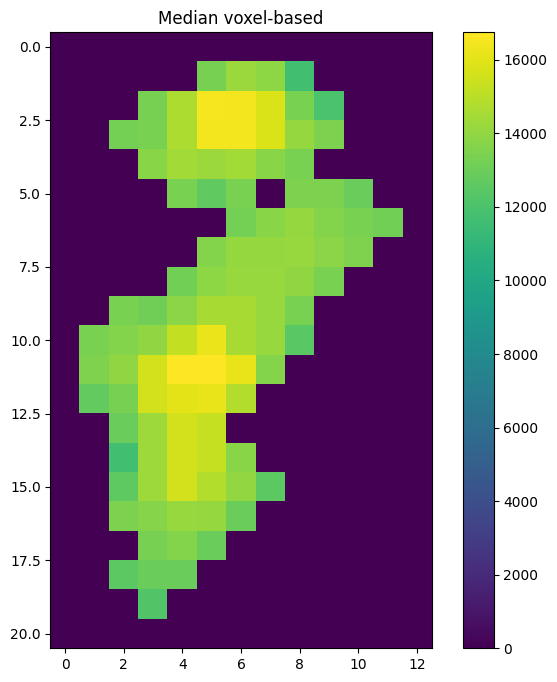

In [52]:
median_img = result_voxel_med[
    "original_firstorder_Median"
]

median_map = sitk.GetArrayFromImage(
    median_img
)

print(median_map.shape)

median_2d = median_map[0]

plt.figure(figsize=(8,8))
plt.imshow(median_2d)
plt.colorbar()
plt.title("Median voxel-based")
plt.show()

In [53]:
vals = median_2d[median_2d > 0]

print("N:", len(vals))
print("Mean:", vals.mean())
print("Std:", vals.std())

print(
    np.percentile(
        vals,
        [5,25,50,75,95]
    )
)



N: 104
Mean: 14043.954326923076
Std: 1139.0112164250063
[12532.11818848 13357.67749023 13848.046875   14534.36669922
 16448.45581055]


### 1)Primero vamos a calcular el mapa voxel-based de la ROI0:

In [54]:
print(roi_img.shape)
print(mask0.shape)

(79, 116)
(79, 116)


In [55]:
import SimpleITK as sitk
import numpy as np

img_3d = roi_img[np.newaxis, :, :]
mask0_3d = mask0[np.newaxis, :, :]

print(img_3d.shape)
print(mask0_3d.shape)


sitk_img = sitk.GetImageFromArray(
    img_3d.astype(np.float32)
)

sitk_mask0 = sitk.GetImageFromArray(
    mask0_3d.astype(np.uint8)
)

print("Imagen:", sitk_img.GetSize())
print("Mascara:", sitk_mask0.GetSize())
print("Dim:", sitk_img.GetDimension())

(1, 79, 116)
(1, 79, 116)
Imagen: (116, 79, 1)
Mascara: (116, 79, 1)
Dim: 3


In [56]:
from radiomics import featureextractor

extractor_voxel = featureextractor.RadiomicsFeatureExtractor()

extractor_voxel.disableAllFeatures()

extractor_voxel.enableFeaturesByName(
    firstorder=['Median']
)

result_roi0 = extractor_voxel.execute(
    sitk_img,
    sitk_mask0,
    voxelBased=True
)

print("Ejecutado correctamente")

for k in result_roi0.keys():
    print(k)

Ejecutado correctamente
diagnostics_Versions_PyRadiomics
diagnostics_Versions_Numpy
diagnostics_Versions_SimpleITK
diagnostics_Versions_PyWavelet
diagnostics_Versions_Python
diagnostics_Configuration_Settings
diagnostics_Configuration_EnabledImageTypes
diagnostics_Image-original_Hash
diagnostics_Image-original_Dimensionality
diagnostics_Image-original_Spacing
diagnostics_Image-original_Size
diagnostics_Image-original_Mean
diagnostics_Image-original_Minimum
diagnostics_Image-original_Maximum
diagnostics_Mask-original_Hash
diagnostics_Mask-original_Spacing
diagnostics_Mask-original_Size
diagnostics_Mask-original_BoundingBox
diagnostics_Mask-original_VoxelNum
diagnostics_Mask-original_VolumeNum
diagnostics_Mask-original_CenterOfMassIndex
diagnostics_Mask-original_CenterOfMass
original_firstorder_Median


(1, 19, 11)
0.0
17479.6142578125


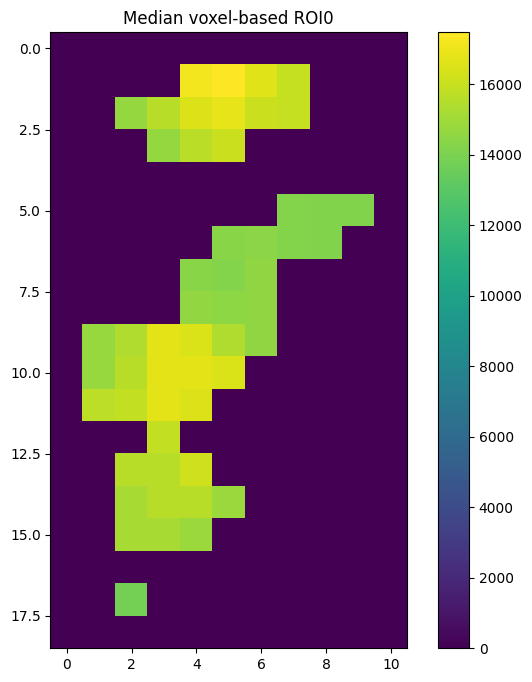

In [57]:
median_img = result_roi0[
    "original_firstorder_Median"
]

median_map = sitk.GetArrayFromImage(
    median_img
)

print(median_map.shape)
print(median_map.min())
print(median_map.max())

median_2d = median_map[0]

plt.figure(figsize=(8,8))
plt.imshow(median_2d)
plt.colorbar()
plt.title("Median voxel-based ROI0")
plt.show()

In [58]:
vals_roi0 = median_2d[median_2d > 0]

print("Número de voxeles:", len(vals_roi0))
print("Media:", vals_roi0.mean())
print("Std:", vals_roi0.std())

print(
    np.percentile(
        vals_roi0,
        [5,25,50,75,95]
    )
)

Número de voxeles: 53
Media: 15442.453309257075
Std: 938.8707377809369
[14148.80664062 14572.77050781 15580.0859375  16079.09570312
 16809.33867188]


(array([1., 6., 5., 7., 2., 3., 2., 8., 4., 3., 0., 7., 3., 1., 1.]),
 array([13816.51953125, 14060.72584635, 14304.93216146, 14549.13847656,
        14793.34479167, 15037.55110677, 15281.75742187, 15525.96373698,
        15770.17005208, 16014.37636719, 16258.58268229, 16502.7889974 ,
        16746.9953125 , 16991.2016276 , 17235.40794271, 17479.61425781]),
 <BarContainer object of 15 artists>)

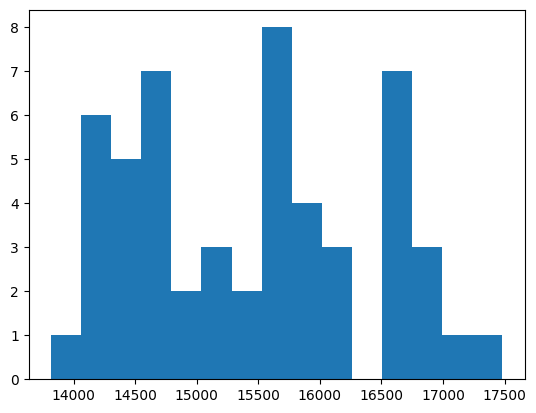

In [59]:
plt.hist(vals_roi0, bins=15)

ROI1

↓

Mapa voxel-based Median

↓

Extraer únicamente los voxeles de Corona1

↓

Comparar contra ROI0

In [60]:
from scipy.ndimage import binary_dilation

mask1 = binary_dilation(mask0)

corona1 = mask1 & (~mask0)

print("ROI0:", mask0.sum())
print("ROI1:", mask1.sum())
print("Corona1:", corona1.sum())

ROI0: 53
ROI1: 104
Corona1: 51


In [61]:
sitk_mask1 = sitk.GetImageFromArray(
    mask1[np.newaxis,:,:].astype(np.uint8)
)

result_roi1 = extractor_voxel.execute(
    sitk_img,
    sitk_mask1,
    voxelBased=True
)

median_map_roi1 = sitk.GetArrayFromImage(
    result_roi1["original_firstorder_Median"]
)

print(median_map_roi1.shape)

(1, 21, 13)


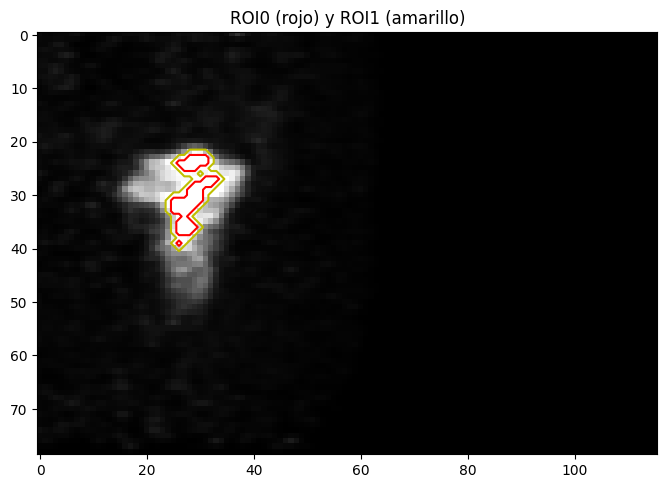

In [62]:
plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.contour(mask0, colors='r')
plt.contour(mask1, colors='y')

plt.title("ROI0 (rojo) y ROI1 (amarillo)")
plt.show()

Hay un problema de coordenadas con el que tenenmos que lidiar


Entonces no podemos hacer directamente:

median_map[corona1]

In [63]:
print(
    result_roi1[
        "diagnostics_Mask-original_BoundingBox"
    ]
)

(24, 22, 0, 11, 19, 1)


In [64]:
print(median_map_roi1.shape)
print(mask1.sum())

median_2d_roi1 = median_map_roi1[0]

print(
    np.count_nonzero(
        median_2d_roi1
    )
)

(1, 21, 13)
104
104


Entonces sí, la opción 1 funciona

Ahora ya podemos reconstruir el mapa en coordenadas de la imagen original.

La idea conceptual es:

median_map_roi1 (21×13)

        ↓

pegarlo en
full_map (79×116)

        ↓
        
full_map[corona1]

In [65]:
median_2d_roi1 = median_map_roi1[0]

print(median_2d_roi1.shape)

(21, 13)


In [66]:
full_map = np.zeros(
    roi_img.shape,
    dtype=float
)

print(full_map.shape)

(79, 116)


In [67]:
bbox = result_roi1[
    "diagnostics_Mask-original_BoundingBox"
]

print(bbox)

(24, 22, 0, 11, 19, 1)


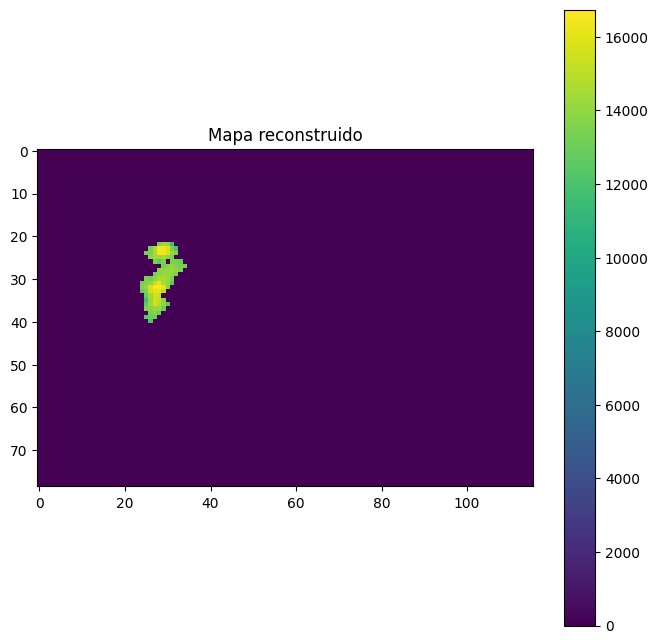

In [68]:
y0 = 22 - 1
x0 = 24 - 1
full_map[
    y0:y0+21,
    x0:x0+13
] = median_2d_roi1

plt.figure(figsize=(8,8))

plt.imshow(full_map)
plt.colorbar()

plt.title("Mapa reconstruido")
plt.show()

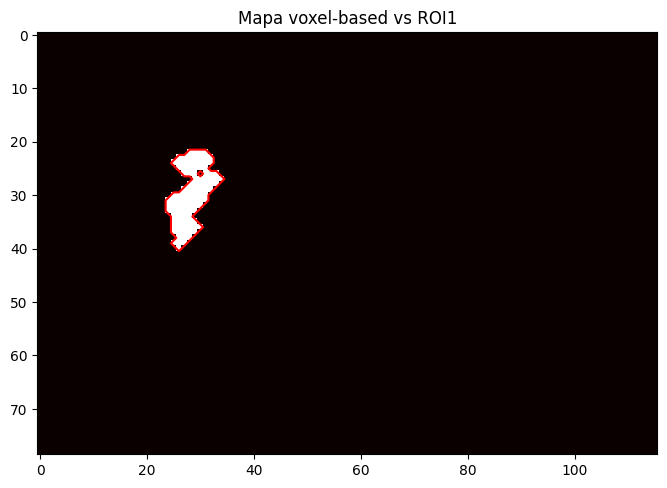

In [69]:
plt.figure(figsize=(8,8))

plt.imshow(full_map > 0, cmap="hot")

plt.contour(mask1, colors="r")

plt.title("Mapa voxel-based vs ROI1")
plt.show()

In [70]:
vals_corona1 = full_map[corona1]

print("Número de voxeles:", len(vals_corona1))
print("Media:", vals_corona1.mean())
print("Std:", vals_corona1.std())

print(
    np.percentile(
        vals_corona1,
        [5,25,50,75,95]
    )
)

Número de voxeles: 51
Media: 13315.527439491421
Std: 692.5486260406791
[12099.18554688 12948.6184082  13365.29833984 13631.34301758
 14513.98144531]


In [71]:
media_roi0 = vals_roi0.mean()
std_roi0   = vals_roi0.std()

lim_inf = media_roi0 - 4*std_roi0
lim_sup = media_roi0 + 4*std_roi0

print(lim_inf)
print(lim_sup)

11686.970358133327
19197.936260380822


In [72]:
aceptados = (
    (vals_corona1 >= lim_inf) &
    (vals_corona1 <= lim_sup)
)

print("Aceptados:", aceptados.sum())
print("Rechazados:", (~aceptados).sum())

Aceptados: 50
Rechazados: 1


verificacion visual

In [73]:
mask_aceptados = np.zeros_like(mask0, dtype=bool)

mask_aceptados[corona1] = aceptados

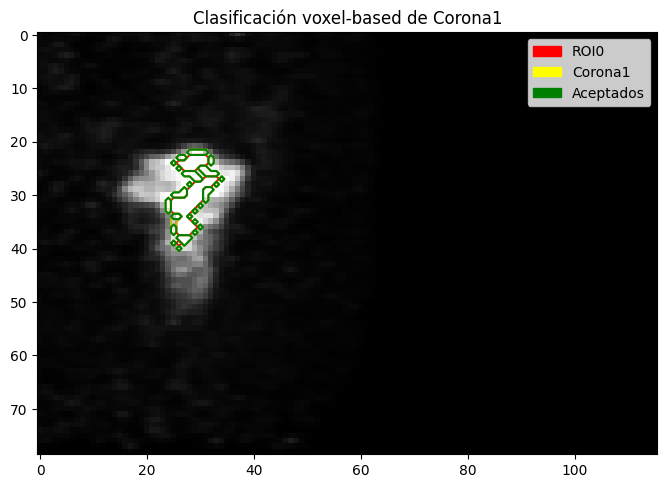

In [74]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.contour(mask0, colors='r')
plt.contour(corona1, colors='y')
plt.contour(mask_aceptados, colors='g')

# Leyenda
roi0_patch = mpatches.Patch(color='red', label='ROI0')
corona_patch = mpatches.Patch(color='yellow', label='Corona1')
aceptados_patch = mpatches.Patch(color='green', label='Aceptados')

plt.legend(
    handles=[
        roi0_patch,
        corona_patch,
        aceptados_patch
    ],
    loc='upper right'
)

plt.title("Clasificación voxel-based de Corona1")
plt.show()

## 2)Hasta aca ayer estaba bien

In [75]:
media_roi0 = vals_roi0.mean()
std_roi0   = vals_roi0.std()

lim_inf = media_roi0 - 10*std_roi0
lim_sup = media_roi0 + 10*std_roi0

print("Media ROI0:", media_roi0)
print("Std ROI0:", std_roi0)
print("Límite inferior:", lim_inf)
print("Límite superior:", lim_sup)

Media ROI0: 15442.453309257075
Std ROI0: 938.8707377809369
Límite inferior: 6053.7459314477055
Límite superior: 24831.160687066444


In [76]:
aceptados = (
    (vals_corona1 >= lim_inf) &
    (vals_corona1 <= lim_sup)
)

print("Aceptados:", aceptados.sum())
print("Rechazados:", (~aceptados).sum())

Aceptados: 51
Rechazados: 0


In [77]:
mask_aceptados = np.zeros_like(
    mask0,
    dtype=bool
)

mask_aceptados[corona1] = aceptados

print(
    "Aceptados:",
    mask_aceptados.sum()
)

Aceptados: 51


In [78]:
roi_next = (
    mask0 |
    mask_aceptados
)

print(
    "ROI0:",
    mask0.sum()
)

print(
    "ROI siguiente:",
    roi_next.sum()
)

ROI0: 53
ROI siguiente: 104


segunda iteracion

In [79]:
roi_actual = roi_next.copy()
print(roi_actual.sum())

104


In [80]:
from scipy.ndimage import binary_dilation

roi_dilatado = binary_dilation(roi_actual)

corona2 = roi_dilatado & (~roi_actual)

print("ROI actual:", roi_actual.sum())
print("ROI dilatado:", roi_dilatado.sum())
print("Corona2:", corona2.sum())

ROI actual: 104
ROI dilatado: 152
Corona2: 48


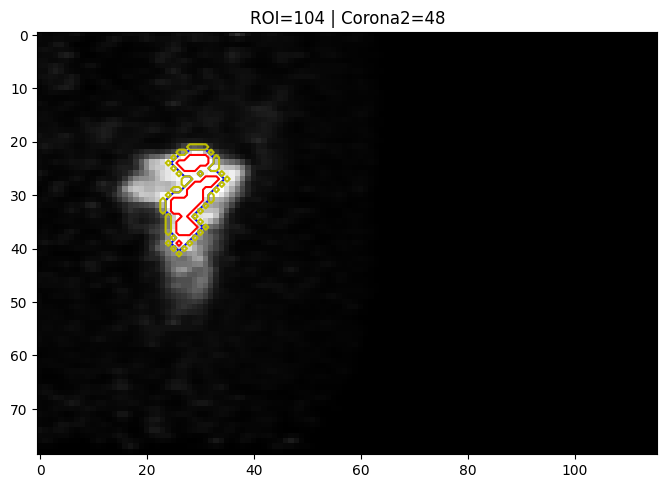

In [81]:
plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.contour(mask0, colors='r')       # ROI0 original
plt.contour(roi_actual, colors='b')  # ROI actual
plt.contour(corona2, colors='y')     # nueva corona

plt.title(
    f"ROI={roi_actual.sum()} | Corona2={corona2.sum()}"
)

plt.show()

In [82]:
import SimpleITK as sitk
import numpy as np

# --------------------------
# ROI dilatado -> formato 3D
# --------------------------

img_3d = roi_img[np.newaxis, :, :]
mask_3d = roi_dilatado.astype(np.uint8)[np.newaxis, :, :]

# --------------------------
# Convertir a SimpleITK
# --------------------------

sitk_img_dilatado = sitk.GetImageFromArray(img_3d)
sitk_mask_dilatado = sitk.GetImageFromArray(mask_3d)

print("Imagen:", sitk_img_dilatado.GetSize())
print("Mascara:", sitk_mask_dilatado.GetSize())
print("Dim:", sitk_img_dilatado.GetDimension())

# --------------------------
# Voxel-based Median
# --------------------------

result_dilatado = extractor_voxel.execute(
    sitk_img_dilatado,
    sitk_mask_dilatado,
    voxelBased=True
)

print("Ejecutado correctamente")

# --------------------------
# Extraer mapa
# --------------------------

median_map_dilatado = sitk.GetArrayFromImage(
    result_dilatado["original_firstorder_Median"]
)

print("Shape mapa:", median_map_dilatado.shape)

# Bounding box
print(
    result_dilatado[
        "diagnostics_Mask-original_BoundingBox"
    ]
)

Imagen: (116, 79, 1)
Mascara: (116, 79, 1)
Dim: 3


Ejecutado correctamente
Shape mapa: (1, 23, 15)
(23, 21, 0, 13, 21, 1)


In [83]:
print(median_map_dilatado.shape)
print(
    result_dilatado[
        "diagnostics_Mask-original_BoundingBox"
    ]
)

(1, 23, 15)
(23, 21, 0, 13, 21, 1)


In [84]:
median_2d_dilatado = median_map_dilatado[0]

full_map_dilatado = np.zeros(
    roi_img.shape,
    dtype=float
)

x = 23
y = 21

# mismo padding de 1 voxel
x0 = x - 1
y0 = y - 1

full_map_dilatado[
    y0:y0+23,
    x0:x0+15
] = median_2d_dilatado

In [85]:
print(np.count_nonzero(full_map_dilatado))
print(roi_dilatado.sum())

152
152


In [86]:
vals_corona2 = full_map_dilatado[corona2]

print("Número de voxeles:", len(vals_corona2))

print("Media:", vals_corona2.mean())
print("Std:", vals_corona2.std())

print(
    np.percentile(
        vals_corona2,
        [5,25,50,75,95]
    )
)

Número de voxeles: 48
Media: 10508.09627465625
Std: 1997.4183785255507
[ 6966.61035415  8978.68608213 10918.93066    12188.58047213
 12762.95921877]


In [87]:
aceptados2 = (
    (vals_corona2 >= lim_inf) &
    (vals_corona2 <= lim_sup)
)

print("Aceptados:", aceptados2.sum())
print("Rechazados:", (~aceptados2).sum())

Aceptados: 47
Rechazados: 1


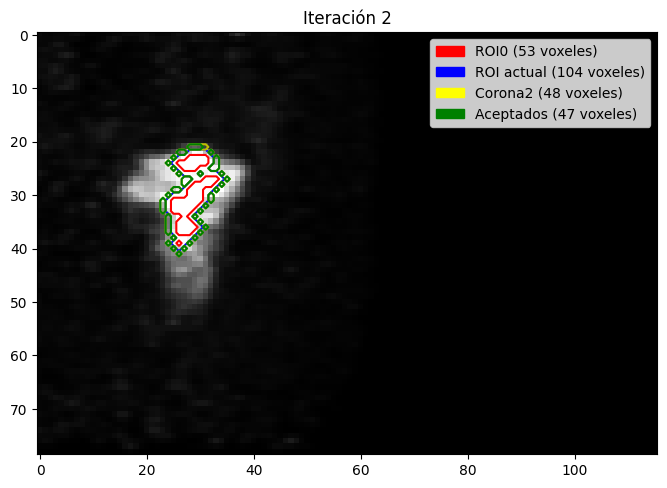

In [88]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
mask_aceptados2 = np.zeros_like(mask0, dtype=bool)

mask_aceptados2[corona2] = aceptados2


plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

# ROI original
plt.contour(mask0, colors='r')

# ROI actual (103 voxeles)
plt.contour(roi_actual, colors='b')

# Corona candidata        # ROI0
plt.contour(corona2, colors='y')        # Corona2
plt.contour(mask_aceptados2, colors='g') # aceptados

roi0_patch = mpatches.Patch(
    color='red',
    label=f'ROI0 ({mask0.sum()} voxeles)'
)

roi_patch = mpatches.Patch(
    color='blue',
    label=f'ROI actual ({roi_actual.sum()} voxeles)'
)

corona_patch = mpatches.Patch(
    color='yellow',
    label=f'Corona2 ({corona2.sum()} voxeles)'
)
aceptados_patch = mpatches.Patch(
    color='green',
    label=f'Aceptados ({mask_aceptados2.sum()} voxeles)'
)
plt.legend(
    handles=[
        roi0_patch,
        roi_patch,
        corona_patch,
        aceptados_patch
    ],
    loc='upper right'
)

plt.title("Iteración 2")
plt.show()

Bucle hasta 10

In [89]:
# Referencia fija de ROI0

media_ref = vals_roi0.mean()
std_ref = vals_roi0.std()

lim_inf_ref = media_ref - 10*std_ref
lim_sup_ref = media_ref + 10*std_ref

print("Media ref:", media_ref)
print("Std ref:", std_ref)
print("Lim inf:", lim_inf_ref)
print("Lim sup:", lim_sup_ref)

resultados = []

Media ref: 15442.453309257075
Std ref: 938.8707377809369
Lim inf: 6053.7459314477055
Lim sup: 24831.160687066444


In [90]:
roi_actual = mask0.copy()

print("Area inicial:", roi_actual.sum())

iteracion = 1

print("Iteración:", iteracion)

Area inicial: 53
Iteración: 1


In [91]:
from scipy.ndimage import binary_dilation

roi_dilatado = binary_dilation(roi_actual)

corona = roi_dilatado & (~roi_actual)

print("ROI actual:", roi_actual.sum())
print("ROI dilatado:", roi_dilatado.sum())
print("Corona:", corona.sum())

ROI actual: 53
ROI dilatado: 104
Corona: 51


In [92]:
# Formato 3D

img_3d = roi_img[np.newaxis, :, :]
mask_3d = roi_dilatado.astype(np.uint8)[np.newaxis, :, :]

# SimpleITK

sitk_img = sitk.GetImageFromArray(img_3d)
sitk_mask = sitk.GetImageFromArray(mask_3d)

# PyRadiomics

result = extractor_voxel.execute(
    sitk_img,
    sitk_mask,
    voxelBased=True
)

# Mapa voxel-based

median_map = sitk.GetArrayFromImage(
    result["original_firstorder_Median"]
)

print("Shape:", median_map.shape)

bbox = result[
    "diagnostics_Mask-original_BoundingBox"
]

print("BoundingBox:", bbox)

Shape: (1, 21, 13)
BoundingBox: (24, 22, 0, 11, 19, 1)


In [93]:
median_2d = median_map[0]

full_map = np.zeros(
    roi_img.shape,
    dtype=float
)

x, y, z, sx, sy, sz = bbox

x0 = x - 1
y0 = y - 1

full_map[
    y0:y0 + median_2d.shape[0],
    x0:x0 + median_2d.shape[1]
] = median_2d

print("No nulos:", np.count_nonzero(full_map))
print("ROI dilatado:", roi_dilatado.sum())

No nulos: 104
ROI dilatado: 104


In [94]:
vals_corona = full_map[corona]

print("Número de voxeles:", len(vals_corona))

print("Media:", vals_corona.mean())
print("Std:", vals_corona.std())

print(
    np.percentile(
        vals_corona,
        [5,25,50,75,95]
    )
)

aceptados = (
    (vals_corona >= lim_inf_ref) &
    (vals_corona <= lim_sup_ref)
)

print("Aceptados:", aceptados.sum())
print("Rechazados:", (~aceptados).sum())

Número de voxeles: 51
Media: 13315.527438715688
Std: 692.5485788522416
[12099.185695   12948.61854925 13365.298406   13631.34291725
 14513.981697  ]
Aceptados: 51
Rechazados: 0


In [95]:
mask_aceptados = np.zeros_like(
    roi_actual,
    dtype=bool
)

mask_aceptados[corona] = aceptados

print(
    "Aceptados en mascara:",
    mask_aceptados.sum()
)

roi_nuevo = (
    roi_actual |
    mask_aceptados
)

print("ROI actual:", roi_actual.sum())
print("ROI nuevo:", roi_nuevo.sum())

Aceptados en mascara: 51
ROI actual: 53
ROI nuevo: 104


In [96]:
resultados = []

resultados.append({
    "iter": 1,
    "roi_size": roi_actual.sum(),
    "corona_size": corona.sum(),
    "accepted": aceptados.sum(),
    "rejected": (~aceptados).sum()
})

import pandas as pd
pd.DataFrame(resultados)

,iter,roi_size,corona_size,accepted,rejected
0,1,53,51,51,0


In [97]:
roi_actual = mask0.copy()
resultados = []

In [98]:
from scipy.ndimage import binary_dilation
import SimpleITK as sitk
import numpy as np
import pandas as pd

# --------------------------
# Inicialización
# --------------------------

roi_actual = mask0.copy()
resultados = []

media_ref = vals_roi0.mean()
std_ref   = vals_roi0.std()

lim_inf_ref = media_ref - 10 * std_ref
lim_sup_ref = media_ref + 10 * std_ref

print("Iteración inicial ROI:", roi_actual.sum())


# --------------------------
# Bucle
# --------------------------

for i in range(1, 4):

    # 1. Dilatación + corona
    roi_dilatado = binary_dilation(roi_actual)
    corona = roi_dilatado & (~roi_actual)

    # 2. Formato 3D
    img_3d = roi_img[np.newaxis, :, :]
    mask_3d = roi_dilatado.astype(np.uint8)[np.newaxis, :, :]

    sitk_img = sitk.GetImageFromArray(img_3d)
    sitk_mask = sitk.GetImageFromArray(mask_3d)

    # 3. Voxel-based Median
    result = extractor_voxel.execute(
        sitk_img,
        sitk_mask,
        voxelBased=True
    )

    median_map = sitk.GetArrayFromImage(
        result["original_firstorder_Median"]
    )[0]

    bbox = result["diagnostics_Mask-original_BoundingBox"]
    x, y, z, sx, sy, sz = bbox

    # 4. Reconstrucción CORREGIDA
    full_map = np.zeros(roi_img.shape, dtype=float)

    h, w = median_map.shape
    x0 = x - 1
    y0 = y - 1

    full_map[
        y0:y0 + h,
        x0:x0 + w
    ] = median_map

    # 5. Extraer corona
    vals = full_map[corona]

    # 6. Clasificación
    aceptados = (
        (vals >= lim_inf_ref) &
        (vals <= lim_sup_ref)
    )

    mask_aceptados = np.zeros_like(roi_actual, dtype=bool)
    mask_aceptados[corona] = aceptados

    # 7. Actualizar ROI
    roi_nuevo = roi_actual | mask_aceptados

    # 8. Guardar resultados
    resultados.append({
        "iter": i,
        "roi_size": roi_actual.sum(),
        "corona_size": corona.sum(),
        "accepted": aceptados.sum(),
        "rejected": (~aceptados).sum(),
        "new_roi_size": roi_nuevo.sum()
    })

    print(f"\nIteración {i}")
    print("ROI:", roi_actual.sum())
    print("Corona:", corona.sum())
    print("Aceptados:", aceptados.sum())
    print("Rechazados:", (~aceptados).sum())
    print("ROI nuevo:", roi_nuevo.sum())

    # 9. avanzar
    roi_actual = roi_nuevo


# --------------------------
# Resultados finales
# --------------------------

df_resultados = pd.DataFrame(resultados)
print("\nRESULTADOS:")
print(df_resultados)

Iteración inicial ROI: 53

Iteración 1
ROI: 53
Corona: 51
Aceptados: 51
Rechazados: 0
ROI nuevo: 104

Iteración 2
ROI: 104
Corona: 48
Aceptados: 47
Rechazados: 1
ROI nuevo: 151

Iteración 3
ROI: 151
Corona: 49
Aceptados: 33
Rechazados: 16
ROI nuevo: 184

RESULTADOS:
   iter  roi_size  corona_size  accepted  rejected  new_roi_size
0     1        53           51        51         0           104
1     2       104           48        47         1           151
2     3       151           49        33        16           184


In [99]:
from scipy.ndimage import binary_dilation
import SimpleITK as sitk
import numpy as np
import pandas as pd

roi_actual = mask0.copy()
resultados = []
historial = []

# referencia fija ROI0
media_ref = vals_roi0.mean()
std_ref   = vals_roi0.std()

lim_inf_ref = media_ref - 10 * std_ref
lim_sup_ref = media_ref + 10 * std_ref


for i in range(1, 16):

    # --------------------------
    # 1. Corona
    # --------------------------
    roi_dilatado = binary_dilation(roi_actual)
    corona = roi_dilatado & (~roi_actual)

    # --------------------------
    # 2. Voxel-based Median
    # --------------------------
    img_3d = roi_img[np.newaxis, :, :]
    mask_3d = roi_dilatado.astype(np.uint8)[np.newaxis, :, :]

    sitk_img = sitk.GetImageFromArray(img_3d)
    sitk_mask = sitk.GetImageFromArray(mask_3d)

    result = extractor_voxel.execute(
        sitk_img,
        sitk_mask,
        voxelBased=True
    )

    median_map = sitk.GetArrayFromImage(
        result["original_firstorder_Median"]
    )[0]

    bbox = result["diagnostics_Mask-original_BoundingBox"]
    x, y, z, sx, sy, sz = bbox

    # --------------------------
    # 3. Reconstrucción
    # --------------------------
    full_map = np.zeros(roi_img.shape, dtype=float)

    h, w = median_map.shape
    x0 = x - 1
    y0 = y - 1

    full_map[
        y0:y0 + h,
        x0:x0 + w
    ] = median_map

    # --------------------------
    # 4. Evaluación corona
    # --------------------------
    vals = full_map[corona]

    aceptados = (
        (vals >= lim_inf_ref) &
        (vals <= lim_sup_ref)
    )

    mask_aceptados = np.zeros_like(roi_actual, dtype=bool)
    mask_aceptados[corona] = aceptados

    # --------------------------
    # 5. Update ROI
    # --------------------------
    roi_nuevo = roi_actual | mask_aceptados

    # --------------------------
    # 6. Guardar
    # --------------------------
    
    resultados.append({
    "iter": i,
    "roi_size": roi_actual.sum(),
    "corona_size": corona.sum(),
    "accepted": aceptados.sum(),
    "rejected": (~aceptados).sum(),
    "new_roi_size": roi_nuevo.sum()
    })

    historial.append({
    "roi_actual": roi_actual.copy(),
    "corona": corona.copy(),
    "mask_aceptados": mask_aceptados.copy()
    })

    print(f"Iter {i}: ROI {roi_actual.sum()} → {roi_nuevo.sum()} | acc {aceptados.sum()} | rej {(~aceptados).sum()}")

    roi_actual = roi_nuevo


df = pd.DataFrame(resultados)
df

Iter 1: ROI 53 → 104 | acc 51 | rej 0
Iter 2: ROI 104 → 151 | acc 47 | rej 1
Iter 3: ROI 151 → 184 | acc 33 | rej 16
Iter 4: ROI 184 → 208 | acc 24 | rej 27
Iter 5: ROI 208 → 233 | acc 25 | rej 29
Iter 6: ROI 233 → 252 | acc 19 | rej 38
Iter 7: ROI 252 → 264 | acc 12 | rej 49
Iter 8: ROI 264 → 271 | acc 7 | rej 57
Iter 9: ROI 271 → 275 | acc 4 | rej 61
Iter 10: ROI 275 → 279 | acc 4 | rej 61
Iter 11: ROI 279 → 282 | acc 3 | rej 62
Iter 12: ROI 282 → 282 | acc 0 | rej 65
Iter 13: ROI 282 → 282 | acc 0 | rej 65
Iter 14: ROI 282 → 282 | acc 0 | rej 65
Iter 15: ROI 282 → 282 | acc 0 | rej 65


,iter,roi_size,corona_size,accepted,rejected,new_roi_size
0,1,53,51,51,0,104
1,2,104,48,47,1,151
2,3,151,49,33,16,184
3,4,184,51,24,27,208
4,5,208,54,25,29,233
5,6,233,57,19,38,252
6,7,252,61,12,49,264
7,8,264,64,7,57,271
8,9,271,65,4,61,275
9,10,275,65,4,61,279


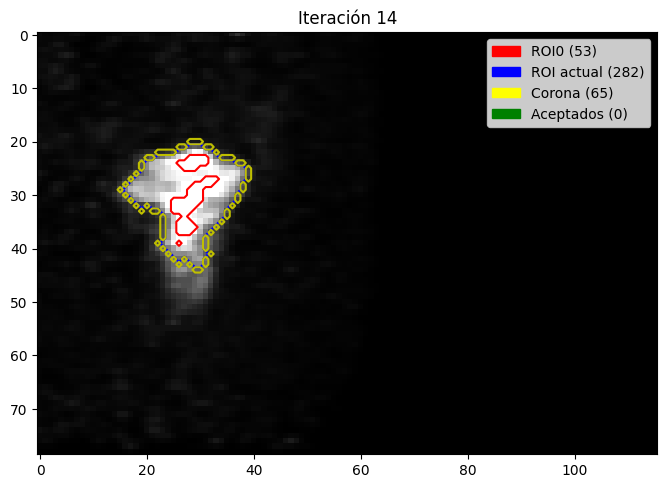

In [100]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

i_vis = 14
data = historial[i_vis - 1]

plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

# Contornos
plt.contour(mask0, colors='r')
plt.contour(data["roi_actual"], colors='b')
plt.contour(data["corona"], colors='y')
plt.contour(data["mask_aceptados"], colors='g')

# --------------------------
# Leyenda
# --------------------------

roi0_patch = mpatches.Patch(
    color='red',
    label=f'ROI0 ({mask0.sum()})'
)

roi_patch = mpatches.Patch(
    color='blue',
    label=f'ROI actual ({data["roi_actual"].sum()})'
)

corona_patch = mpatches.Patch(
    color='yellow',
    label=f'Corona ({data["corona"].sum()})'
)

aceptados_patch = mpatches.Patch(
    color='green',
    label=f'Aceptados ({data["mask_aceptados"].sum()})'
)

plt.legend(
    handles=[
        roi0_patch,
        roi_patch,
        corona_patch,
        aceptados_patch
    ],
    loc='upper right'
)

plt.title(f"Iteración {i_vis}")
plt.show()